# ProBuild Home Centers — Paint Pricing Optimization
**Objective:** Find the prices for SKU_B_Int_Standard and SKU_D_Ext_Premium 
that maximize total gross margin across all 30 stores.


**Methodology layers:**
1. Data audit & quality handling
2. Exploratory Data Analysis
3. OLS log-log + semi log elasticity baselines
4. XGBoost demand model + price sweep
5. Retrospective quasi-experiment (causal inference)
6. Segmented elasticity (by season, store cluster)
7. Cross-price cannibalization analysis
8. Confidence intervals + risk sensitivity table
9. Prospective A/B test design with power analysis
10. Final recommendation with financial impact

## Imports & Configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy import stats
from scipy.optimize import minimize_scalar
from scipy.stats import ttest_ind, mannwhitneyu
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.sandbox.regression.gmm import IV2SLS

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance

import xgboost as xgb

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mtick
from matplotlib.gridspec import GridSpec
import seaborn as sns

pd.set_option('display.max_columns', None)

np.random.seed(42)

HD_ORANGE = '#F96302'
HD_DARK   = '#1A1A1A'
HD_LIGHT  = '#F8F8F8'
BLUE      = '#1565C0'
GREEN     = '#2E7D32'
RED       = '#C62828'
PURPLE    = '#6A1B9A'
TEAL      = '#00695C'

plt.rcParams.update({
    'figure.facecolor' : HD_LIGHT,
    'axes.facecolor'   : 'white',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.titleweight' : 'bold',
    'axes.titlesize'   : 12,
    'font.family'      : 'DejaVu Sans',
    'figure.dpi'       : 120,
})

TARGET_SKUS = ['SKU_B_Int_Standard', 'SKU_D_Ext_Premium']
SCALE       = 365 * 30   # store-days per year

print('Libraries loaded')


Libraries loaded


## Data Loading

In [2]:
df = pd.read_csv("/kaggle/input/datasets/neshatsharbatdar/probuild-paint-data/probuild_paint_data.csv", parse_dates=['date'])
df

,date,store_id,category,sku,price,unit_cost,beginning_inventory,sales_units
0,2023-01-05,STR_018,Interior,SKU_C_Int_Budget,26.52,15.0,34,34
1,2021-12-23,STR_010,Interior,SKU_C_Int_Budget,19.01,15.0,92,53
2,2022-05-30,STR_003,Interior,SKU_A_Int_Premium,50.96,30.0,71,0
3,2022-06-15,STR_022,Interior,SKU_C_Int_Budget,22.50,15.0,28,28
4,2023-05-01,STR_021,Exterior,SKU_E_Ext_Standard,46.35,25.0,53,53
...,...,...,...,...,...,...,...,...
161995,2022-01-31,STR_030,Exterior,SKU_E_Ext_Standard,46.86,25.0,60,24
161996,2023-01-27,STR_015,Exterior,SKU_D_Ext_Premium,56.66,35.0,28,28
161997,2023-03-09,STR_023,Exterior,SKU_E_Ext_Standard,45.35,25.0,82,0
161998,2022-01-31,STR_018,Exterior,SKU_F_Ext_Budget,26.87,18.0,57,57


In [3]:
# Full row duplicates
full_dupes = df.duplicated().sum()
print(f'  Full duplicate rows        : {full_dupes:,}')

# Business-key duplicates: same store + date + SKU should be unique
key_dupes = df.duplicated(subset=['store_id', 'date', 'sku']).sum()
print(f'  Store-date-SKU duplicates  : {key_dupes:,}')

if key_dupes == 0:
    print(f'Each store-date-SKU combination appears exactly once.')
    print(f'Data is at the correct granularity for demand modelling.')
else:
    print(f'{key_dupes:,} duplicate store-date-SKU rows found.')
    print(f'These would inflate unit counts and bias model training.')
    print(f'Investigate before proceeding.')
    dupes_sample = df[df.duplicated(subset=['store_id','date','sku'], keep=False)]
    print(f'\n  Sample duplicate rows:')
    display(dupes_sample.head(10))

  Full duplicate rows        : 0
  Store-date-SKU duplicates  : 0
Each store-date-SKU combination appears exactly once.
Data is at the correct granularity for demand modelling.


In [4]:
# Feature engineering
df['year']       = df['date'].dt.year
df['month']      = df['date'].dt.month
df['quarter']    = df['date'].dt.quarter
df['dayofweek']  = df['date'].dt.dayofweek
df['week']       = df['date'].dt.isocalendar().week.astype(int)
df['dayofyear']  = df['date'].dt.dayofyear

# Seasonal Fourier terms
df['seasonal_sin'] = np.sin(2 * np.pi * df['dayofyear'] / 365)
df['seasonal_cos'] = np.cos(2 * np.pi * df['dayofyear'] / 365)

# Financial columns
df['revenue']      = df['price'] * df['sales_units']
df['cogs']         = df['unit_cost'] * df['sales_units']
df['gross_margin'] = df['revenue'] - df['cogs']
df['gm_pct']       = np.where(df['revenue'] > 0,
                               df['gross_margin'] / df['revenue'] * 100, np.nan)

df['margin_per_unit'] = df['price'] - df['unit_cost']
df['price_to_cost']   = df['price'] / df['unit_cost']
df['zero_sale']       = df['sales_units'] == 0

# Log transforms (will be used in OLS)
df['ln_units'] = np.where(df['sales_units'] > 0, np.log(df['sales_units']), np.nan)
df['ln_price'] = np.log(df['price'])
df['ln_inv']   = np.log(df['beginning_inventory'].clip(lower=1))

print(f'Dataset shape  : {df.shape}')
print(f'Date range     : {df.date.min().date()} → {df.date.max().date()}')
print(f'Stores         : {df.store_id.nunique()}')
print(f'SKUs           : {df.sku.nunique()}')
print(f'Total rows     : {len(df):,}')

df

Dataset shape  : (162000, 26)
Date range     : 2021-01-01 → 2023-06-19
Stores         : 30
SKUs           : 6
Total rows     : 162,000


,date,store_id,category,sku,price,unit_cost,beginning_inventory,sales_units,year,month,quarter,dayofweek,week,dayofyear,seasonal_sin,seasonal_cos,revenue,cogs,gross_margin,gm_pct,margin_per_unit,price_to_cost,zero_sale,ln_units,ln_price,ln_inv
0,2023-01-05,STR_018,Interior,SKU_C_Int_Budget,26.52,15.0,34,34,2023,1,1,3,1,5,0.085965,0.996298,901.68,510.0,391.68,43.438914,11.52,1.768000,False,3.526361,3.277899,3.526361
1,2021-12-23,STR_010,Interior,SKU_C_Int_Budget,19.01,15.0,92,53,2021,12,4,3,51,357,-0.137279,0.990532,1007.53,795.0,212.53,21.094161,4.01,1.267333,False,3.970292,2.944965,4.521789
2,2022-05-30,STR_003,Interior,SKU_A_Int_Premium,50.96,30.0,71,0,2022,5,2,0,22,150,0.530730,-0.847541,0.00,0.0,0.00,NaN,20.96,1.698667,True,NaN,3.931041,4.262680
3,2022-06-15,STR_022,Interior,SKU_C_Int_Budget,22.50,15.0,28,28,2022,6,2,2,24,166,0.280231,-0.959933,630.00,420.0,210.00,33.333333,7.50,1.500000,False,3.332205,3.113515,3.332205
4,2023-05-01,STR_021,Exterior,SKU_E_Ext_Standard,46.35,25.0,53,53,2023,5,2,0,18,121,0.871706,-0.490029,2456.55,1325.0,1131.55,46.062567,21.35,1.854000,False,3.970292,3.836221,3.970292
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161995,2022-01-31,STR_030,Exterior,SKU_E_Ext_Standard,46.86,25.0,60,24,2022,1,1,0,5,31,0.508671,0.860961,1124.64,600.0,524.64,46.649595,21.86,1.874400,False,3.178054,3.847164,4.094345
161996,2023-01-27,STR_015,Exterior,SKU_D_Ext_Premium,56.66,35.0,28,28,2023,1,1,4,4,27,0.448229,0.893919,1586.48,980.0,606.48,38.228027,21.66,1.618857,False,3.332205,4.037068,3.332205
161997,2023-03-09,STR_023,Exterior,SKU_E_Ext_Standard,45.35,25.0,82,0,2023,3,1,3,10,68,0.920971,0.389630,0.00,0.0,0.00,NaN,20.35,1.814000,True,NaN,3.814410,4.406719
161998,2022-01-31,STR_018,Exterior,SKU_F_Ext_Budget,26.87,18.0,57,57,2022,1,1,0,5,31,0.508671,0.860961,1531.59,1026.0,505.59,33.010793,8.87,1.492778,False,4.043051,3.291010,4.043051


## Data Quality Audit

In [5]:
# Null audit
nulls = df.isnull().sum()
print('\n ** Null counts:')
print(nulls[nulls > 0].to_string() if nulls.sum() > 0 else '  None — clean dataset')


 ** Null counts:
gm_pct      20321
ln_units    20321


In [6]:
# Sanity flags
flags = {
    'Negative sales_units'       : (df['sales_units'] < 0).sum(),
    'Zero/negative price'        : (df['price'] <= 0).sum(),
    'Price below unit_cost'      : (df['price'] < df['unit_cost']).sum(),
    'Sales > beginning_inventory': (df['sales_units'] > df['beginning_inventory']).sum(),
    'Zero-sale rows'             : df['zero_sale'].sum(),
}
print('\n ** Sanity flags:')
for k, v in flags.items():
    pct    = f'  ({v/len(df)*100:.1f}%)' if v > 0 else ''
    print(f'  {k:<35}: {v:,}{pct}')


 ** Sanity flags:
  Negative sales_units               : 0
  Zero/negative price                : 0
  Price below unit_cost              : 847  (0.5%)
  Sales > beginning_inventory        : 0
  Zero-sale rows                     : 20,321  (12.5%)


In [7]:
# Below-cost price investigation
print('\n ** Below-cost price investigation:')
print('847 rows (0.5%) have price < unit_cost')
print('These represent loss-making transactions — not normal pricing')


below_cost = df[df['price'] < df['unit_cost']].copy()

# How far below cost?
below_cost['discount_pct'] = (below_cost['unit_cost'] - below_cost['price']) / below_cost['unit_cost'] * 100

print('  Distribution of below-cost rows by SKU:')
bc_summary = below_cost.groupby('sku').agg(
    count        = ('price', 'count'),
    min_price    = ('price', 'min'),
    max_price    = ('price', 'max'),
    avg_unit_cost     = ('unit_cost', 'mean'),
    avg_discount = ('discount_pct', 'mean')
).round(2)
print(bc_summary.to_string())
print()

# Are they clustered in specific stores or dates?
print('  Top stores with below-cost rows:')
print(below_cost.groupby('store_id').size()
      .sort_values(ascending=False).head(5).to_string())
print()

print('  Are they clustered in time?')
below_cost['year_month'] = below_cost['date'].dt.to_period('M')
monthly = below_cost.groupby('year_month').size()
print(f'  Months with below-cost rows: {len(monthly)}')
print(f'  Max in one month: {monthly.max()}')


 ** Below-cost price investigation:
847 rows (0.5%) have price < unit_cost
These represent loss-making transactions — not normal pricing
  Distribution of below-cost rows by SKU:
                    count  min_price  max_price  avg_unit_cost  avg_discount
sku                                                                         
SKU_A_Int_Premium     145       4.07       5.96           30.0         83.28
SKU_B_Int_Standard    151       3.35       3.50           22.0         84.11
SKU_C_Int_Budget      144       1.80      14.99           15.0         74.99
SKU_D_Ext_Premium     136       5.18       6.20           35.0         83.62
SKU_E_Ext_Standard    135       3.59       5.35           25.0         82.08
SKU_F_Ext_Budget      136       2.25      17.44           18.0         82.98

  Top stores with below-cost rows:
store_id
STR_027    36
STR_017    35
STR_020    34
STR_023    34
STR_004    34

  Are they clustered in time?
  Months with below-cost rows: 30
  Max in one month: 42


In [8]:
# Likely stockout flag 
# When sales_units >= beginning_inventory, the store likely sold out
# True demand on those days is CENSORED — we only know demand >= observed sales
df['likely_stockout'] = (df['sales_units'] >= df['beginning_inventory']).astype(int)

stockout_by_sku = (df.groupby('sku')['likely_stockout']
                     .agg(['sum', 'mean'])
                     .rename(columns={'sum': 'Stockout rows', 'mean': 'Rate'}))
stockout_by_sku['Rate'] = (stockout_by_sku['Rate'] * 100).round(1).astype(str) + '%'

print('\n ** Likely stockout rate by SKU (sales >= beginning_inventory):')
print(stockout_by_sku.to_string())
print()
print('Where sales = inventory, true demand is CENSORED.')
print('We only know demand was AT LEAST that many units.')
print('Price elasticity on these days is unreliable — high-price + stockout looks like "demand held up at high price when in reality we simply ran out of stock.')

print('Action: exclude likely-stockout rows from demand models in addition to zero-sale rows.')


 ** Likely stockout rate by SKU (sales >= beginning_inventory):
                    Stockout rows   Rate
sku                                     
SKU_A_Int_Premium            4568  16.9%
SKU_B_Int_Standard           5464  20.2%
SKU_C_Int_Budget            18055  66.9%
SKU_D_Ext_Premium            4197  15.5%
SKU_E_Ext_Standard          10013  37.1%
SKU_F_Ext_Budget            17908  66.3%

Where sales = inventory, true demand is CENSORED.
We only know demand was AT LEAST that many units.
Price elasticity on these days is unreliable — high-price + stockout looks like "demand held up at high price when in reality we simply ran out of stock.
Action: exclude likely-stockout rows from demand models in addition to zero-sale rows.


In [9]:
# Price variation audit
print('\n ** Price variation per SKU (critical for elasticity modelling):')
price_var = (df.groupby('sku')['price']
               .agg(['nunique', 'min', 'max', 'std', 'mean'])
               .round(2))
price_var['cv%'] = (price_var['std'] / price_var['mean'] * 100).round(1)
price_var.columns = ['N unique prices', 'Min', 'Max', 'Std', 'Mean', 'CV%']
print(price_var.to_string())
print()
print('  SKU_B: only 4 unique prices — limited variation for OLS elasticity estimation')
print('  SKU_D: 986 unique prices — sufficient variation, OLS should be reliable')
print('  Where price variation is limited, XGBoost provides a more robust estimate by learning demand patterns across store and seasonal dimensions')


 ** Price variation per SKU (critical for elasticity modelling):
                    N unique prices   Min    Max   Std   Mean   CV%
sku                                                                
SKU_A_Int_Premium              2323  4.07  65.37  5.16  49.76  10.4
SKU_B_Int_Standard                4  3.35  35.00  2.37  34.75   6.8
SKU_C_Int_Budget               1849  1.80  37.93  3.37  24.87  13.6
SKU_D_Ext_Premium               986  5.18  62.00  5.06  57.04   8.9
SKU_E_Ext_Standard             2094  3.59  58.86  4.52  44.77  10.1
SKU_F_Ext_Budget               1832  2.25  43.67  3.53  29.85  11.8

  SKU_B: only 4 unique prices — limited variation for OLS elasticity estimation
  SKU_D: 986 unique prices — sufficient variation, OLS should be reliable
  Where price variation is limited, XGBoost provides a more robust estimate by learning demand patterns across store and seasonal dimensions


In [10]:
df_B = df[df['sku'] == 'SKU_B_Int_Standard']
print(df_B['price'].unique())

[35.   33.5   3.5   3.35]


In [11]:
# Seasonal price variation — did the pricing team raise prices seasonally?
print('\n ** Price distribution by season:')
print('If prices are higher in high-demand seasons, elasticity estimates will be biased toward zero.')


season_map = {12: 'Winter', 1: 'Winter', 2: 'Winter',
              3:  'Spring', 4: 'Spring', 5: 'Spring',
              6:  'Summer', 7: 'Summer', 8: 'Summer',
              9:  'Fall',  10: 'Fall',  11: 'Fall'}
df['season'] = df['month'].map(season_map)

for sku in ['SKU_B_Int_Standard', 'SKU_D_Ext_Premium']:
    print(f'  {sku}:')
    season_price = (df[df['sku']==sku]
                    .groupby('season')['price']
                    .agg(['mean','std','min','max'])
                    .round(2))
    season_price.columns = ['Mean price', 'Std', 'Min', 'Max']
    print(season_price.to_string())
    
    # Check if seasonal price variation is meaningful
    price_range = season_price['Mean price'].max() - season_price['Mean price'].min()
    overall_mean = df[df['sku']==sku]['price'].mean()
    pct_variation = price_range / overall_mean * 100
    
    print(f'\n  Seasonal price range: ${price_range:.2f} '
          f'({pct_variation:.1f}% of mean price)')
    
    if pct_variation < 2:
        print(f'Prices are essentially uniform across seasons.')
        print(f'Endogeneity from seasonal pricing is negligible.')
    elif pct_variation < 5:
        print(f'Minor seasonal price variation detected.')
        print(f'Seasonal controls in OLS partially mitigate this.')
    else:
        print(f'Meaningful seasonal price variation detected.')
        print(f'Elasticity estimates may be biased — interpret with caution.')


 ** Price distribution by season:
If prices are higher in high-demand seasons, elasticity estimates will be biased toward zero.
  SKU_B_Int_Standard:
        Mean price   Std   Min   Max
season                              
Fall         34.75  2.31  3.50  35.0
Spring       34.76  2.26  3.35  35.0
Summer       34.74  2.49  3.35  35.0
Winter       34.74  2.42  3.35  35.0

  Seasonal price range: $0.02 (0.1% of mean price)
Prices are essentially uniform across seasons.
Endogeneity from seasonal pricing is negligible.
  SKU_D_Ext_Premium:
        Mean price   Std   Min    Max
season                               
Fall         54.80  3.34  5.28  61.23
Spring       57.11  5.03  5.25  62.00
Summer       61.68  4.22  6.20  62.00
Winter       54.73  4.02  5.18  61.98

  Seasonal price range: $6.95 (12.2% of mean price)
Meaningful seasonal price variation detected.
Elasticity estimates may be biased — interpret with caution.


In [12]:
# Cost variation audit
print('\n ** Cost variation per SKU (affects margin calculation):')
cost_var = (df.groupby('sku')['unit_cost']
              .agg(['nunique', 'min', 'max', 'std', 'mean'])
              .round(2))

cost_var.columns = ['N unique costs', 'Min', 'Max', 'Std', 'Mean']
print(cost_var.to_string())
print('  We have unique cost for each SKU.')


 ** Cost variation per SKU (affects margin calculation):
                    N unique costs   Min   Max  Std  Mean
sku                                                      
SKU_A_Int_Premium                1  30.0  30.0  0.0  30.0
SKU_B_Int_Standard               1  22.0  22.0  0.0  22.0
SKU_C_Int_Budget                 1  15.0  15.0  0.0  15.0
SKU_D_Ext_Premium                1  35.0  35.0  0.0  35.0
SKU_E_Ext_Standard               1  25.0  25.0  0.0  25.0
SKU_F_Ext_Budget                 1  18.0  18.0  0.0  18.0
  We have unique cost for each SKU.


In [13]:
# Zero-sale breakdown by SKU 
print('\n ** Zero-sale rate by SKU:')
zero_by_sku = df.groupby('sku')['zero_sale'].agg(['sum', 'mean'])
zero_by_sku.columns = ['Zero-sale rows', 'Rate']
zero_by_sku['Rate'] = (zero_by_sku['Rate'] * 100).round(1).astype(str) + '%'
print(zero_by_sku.to_string())

print('Zero-sale rows may be stockouts (censored demand) or genuine no-demand.')
print('Excluded from demand models but tracked as a signal.')

# Zero-sale inventory investigation 
# Key question: are zero-sale days because of empty shelves or genuine no-demand?
print('\n ** Zero-sale inventory investigation:')
print()

zero_rows = df[df['zero_sale']].copy()
total_zero = len(zero_rows)

# Category 1 — zero inventory: store had nothing to sell, zero sale is certain
zero_inv = (zero_rows['beginning_inventory'] == 0).sum()

# Category 2 — near-zero inventory: 1-4 units, likely sold out during the day
near_zero_inv = ((zero_rows['beginning_inventory'] > 0) &
                 (zero_rows['beginning_inventory'] < 5)).sum()

# Category 3 — adequate inventory: shelves had stock but nothing sold
adequate_inv = (zero_rows['beginning_inventory'] >= 5).sum()

# Combined inventory-constrained zeros
stockout_driven = zero_inv + near_zero_inv

print(f'  {"Category":<45} {"Rows":>7}  {"% of zeros":>10}')
print('  ' + '─' * 65)
print(f'  {"Zero inventory (inv = 0) — certain stockout":<45} '
      f'{zero_inv:>7,}  {zero_inv/total_zero*100:>9.1f}%')
print(f'  {"Near-zero inventory (inv 1-4) — likely stockout":<45} '
      f'{near_zero_inv:>7,}  {near_zero_inv/total_zero*100:>9.1f}%')
print(f'  {"Adequate inventory (inv ≥ 5) — genuine no-demand":<45} '
      f'{adequate_inv:>7,}  {adequate_inv/total_zero*100:>9.1f}%')
print('  ' + '─' * 65)
print(f'  {"Total zero-sale rows":<45} '
      f'{total_zero:>7,}  {"100.0%":>10}')
print()
print(f'  Inventory-constrained zeros (inv < 5): '
      f'{stockout_driven:,}  ({stockout_driven/total_zero*100:.1f}%)')
print(f'  Genuine no-demand zeros    (inv ≥ 5): '
      f'{adequate_inv:,}  ({adequate_inv/total_zero*100:.1f}%)')
print()

if stockout_driven / total_zero < 0.05:
    print(f'Only {stockout_driven/total_zero*100:.1f}% of zero-sale rows are')
    print(f'inventory-constrained. The vast majority ({adequate_inv/total_zero*100:.1f}%)')
    print(f'had adequate stock but genuinely sold nothing.')
    print(f'Conclusion: zero-sale exclusion from demand models is justified.')
    print(f'These rows add noise without price signal, not hidden demand.')
else:
    print(f'{stockout_driven/total_zero*100:.1f}% of zero-sale rows are inventory-')
    print(f'constrained. Some zeros may represent hidden demand.')
    print(f'This introduces a small conservative bias in elasticity estimates.')



 ** Zero-sale rate by SKU:
                    Zero-sale rows   Rate
sku                                      
SKU_A_Int_Premium             6363  23.6%
SKU_B_Int_Standard            4554  16.9%
SKU_C_Int_Budget                41   0.2%
SKU_D_Ext_Premium             6843  25.3%
SKU_E_Ext_Standard            2463   9.1%
SKU_F_Ext_Budget                57   0.2%
Zero-sale rows may be stockouts (censored demand) or genuine no-demand.
Excluded from demand models but tracked as a signal.

 ** Zero-sale inventory investigation:

  Category                                         Rows  % of zeros
  ─────────────────────────────────────────────────────────────────
  Zero inventory (inv = 0) — certain stockout       261        1.3%
  Near-zero inventory (inv 1-4) — likely stockout      22        0.1%
  Adequate inventory (inv ≥ 5) — genuine no-demand  20,038       98.6%
  ─────────────────────────────────────────────────────────────────
  Total zero-sale rows                           20,321  

In [14]:
# Summary of rows available for modelling
print('\n ** Rows available for demand modelling (after exclusions):')
for sku in ['SKU_B_Int_Standard', 'SKU_D_Ext_Premium']:
    total = (df['sku'] == sku).sum()
    n_zero = ((df['sku'] == sku) & df['zero_sale']).sum()
    n_stockout = ((df['sku'] == sku) & df['likely_stockout'].astype(bool)).sum()

    # Union — handles rows that are both zero-sale AND stockout
    excluded = ((df['sku'] == sku) & (
        df['zero_sale'] |
        df['likely_stockout'].astype(bool)
    )).sum()

    clean = total - excluded
    overlap = n_zero + n_stockout - excluded

    print(f'{sku}:')
    print(f'Total rows: {total:,}')
    print(f'Zero-sale rows: {n_zero:,}  ({n_zero/total*100:.1f}%)')
    print(f'Stockout rows: {n_stockout:,}  ({n_stockout/total*100:.1f}%)')
    if overlap > 0:
        print(f'Overlap (both flags): {overlap:,}  (not double-counted)')
    print(f'Total excluded (union): {excluded:,}  ({excluded/total*100:.1f}%)')
    print(f'Clean rows for model: {clean:,}  ({clean/total*100:.1f}%)')
    print(f'Verification: {excluded:,} + {clean:,} = {excluded+clean:,}')



 ** Rows available for demand modelling (after exclusions):
SKU_B_Int_Standard:
Total rows: 27,000
Zero-sale rows: 4,554  (16.9%)
Stockout rows: 5,464  (20.2%)
Overlap (both flags): 39  (not double-counted)
Total excluded (union): 9,979  (37.0%)
Clean rows for model: 17,021  (63.0%)
Verification: 9,979 + 17,021 = 27,000
SKU_D_Ext_Premium:
Total rows: 27,000
Zero-sale rows: 6,843  (25.3%)
Stockout rows: 4,197  (15.5%)
Overlap (both flags): 37  (not double-counted)
Total excluded (union): 11,003  (40.8%)
Clean rows for model: 15,997  (59.2%)
Verification: 11,003 + 15,997 = 27,000


## EDA: Portfolio Overview

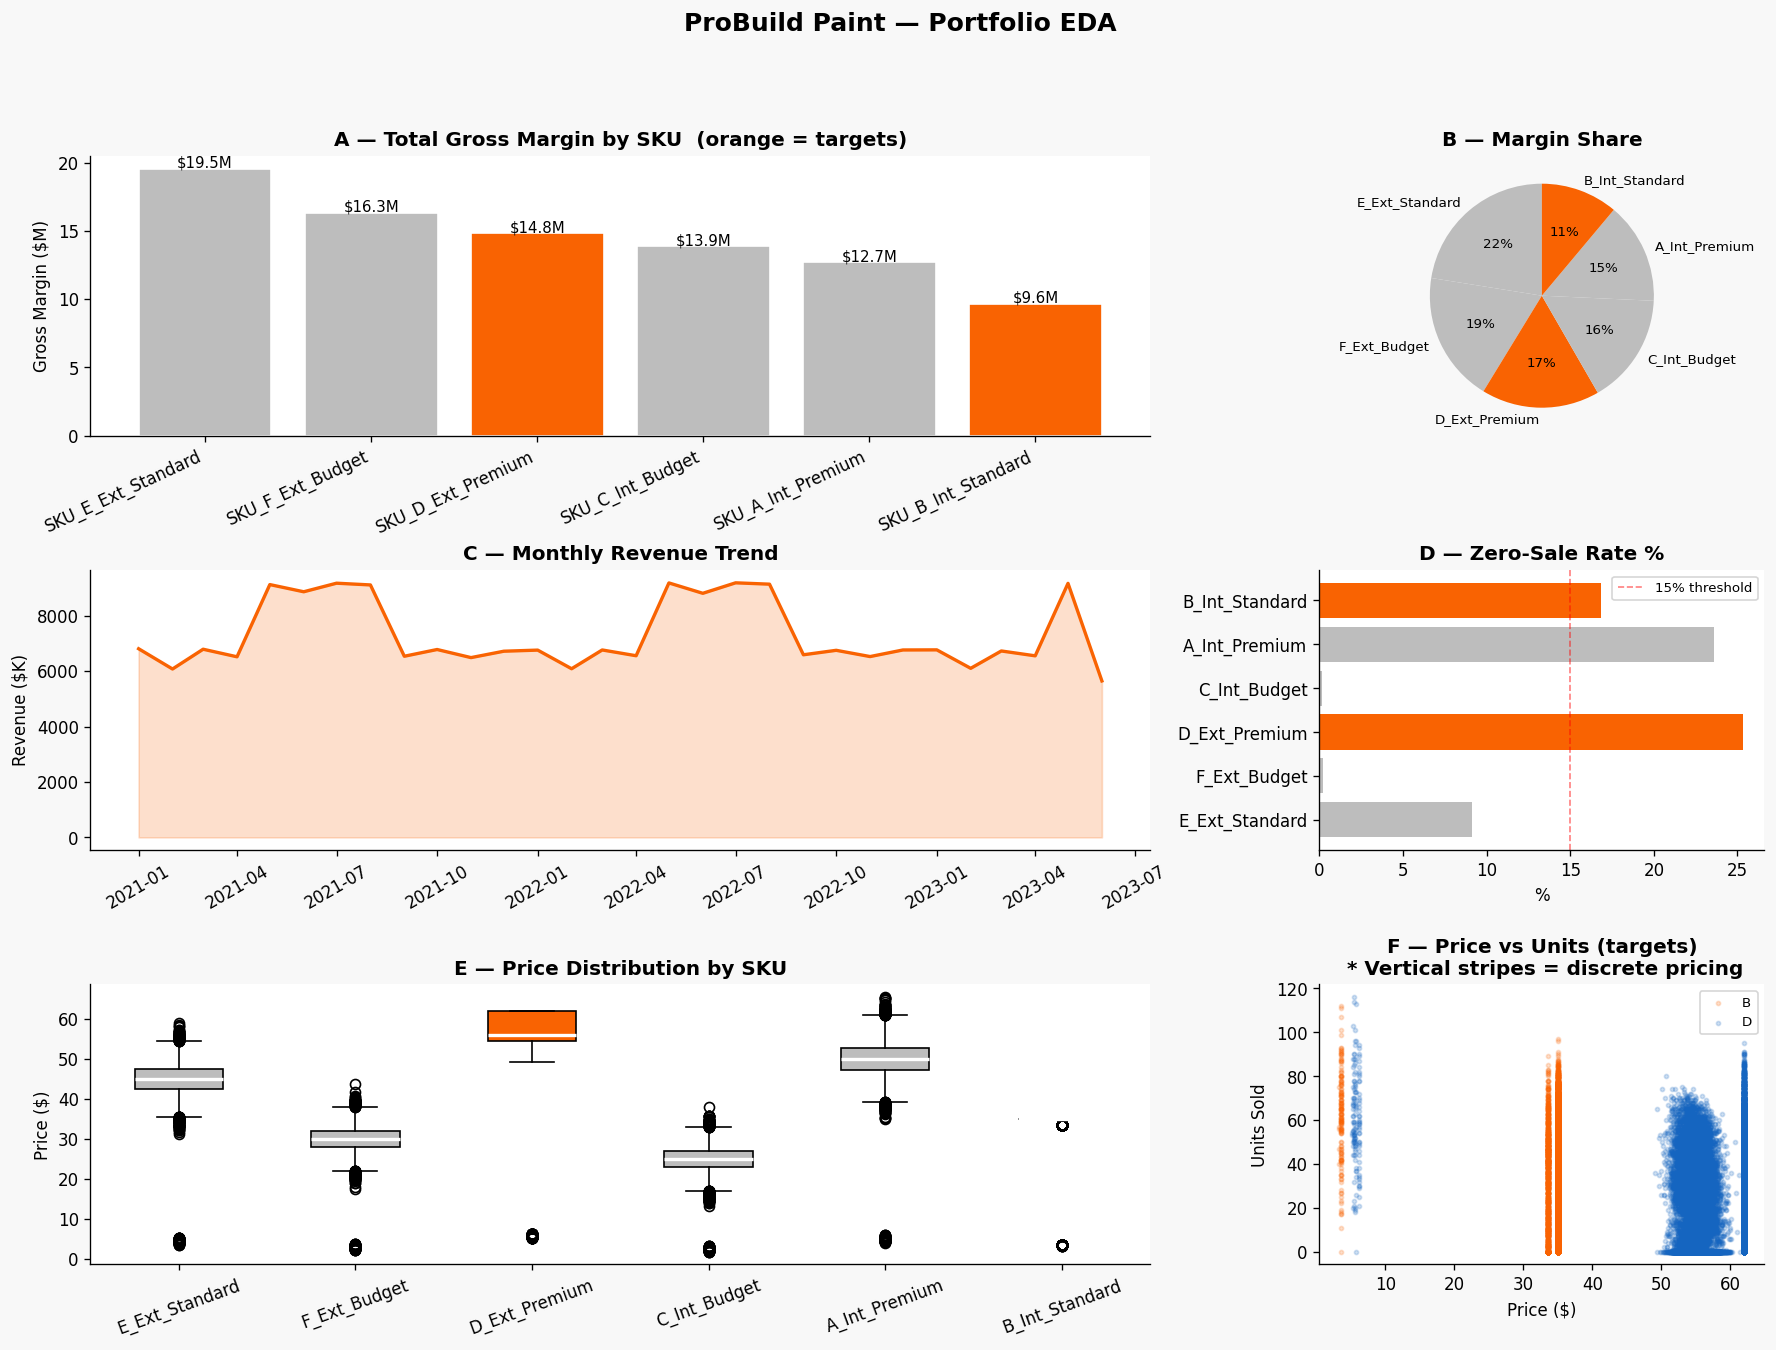


** SKU Summary Table:


,transactions,total_units,total_revenue,total_margin,avg_price,price_std,avg_gm_pct,zero_rate,margin_share
sku,,,,,,,,,
SKU_E_Ext_Standard,27000,1013797,44869135.02,19524210.02,44.77,4.52,41.01,0.09,22.47
SKU_F_Ext_Budget,27000,1394604,41434235.11,16331363.11,29.85,3.53,36.58,0.00,18.80
SKU_D_Ext_Premium,27000,659985,37919695.46,14820220.46,57.04,5.06,35.55,0.25,17.06
SKU_C_Int_Budget,27000,1422581,35196830.38,13858115.38,24.87,3.37,36.43,0.00,15.95
SKU_A_Int_Premium,27000,680788,33128322.65,12704682.65,49.76,5.16,35.20,0.24,14.62
SKU_B_Int_Standard,27000,769094,26565450.25,9645382.25,34.75,2.37,33.21,0.17,11.10


In [15]:
sku_agg = (df.groupby('sku').agg(
    transactions = ('sales_units', 'count'),
    total_units = ('sales_units', 'sum'),
    total_revenue  = ('revenue', 'sum'),
    total_margin = ('gross_margin', 'sum'),
    avg_price = ('price', 'mean'),
    price_std = ('price', 'std'),
    avg_gm_pct = ('gm_pct', 'mean'),
    zero_rate = ('zero_sale', 'mean'),
).assign(
    margin_share = lambda x: x['total_margin'] / x['total_margin'].sum() * 100
).sort_values('total_margin', ascending=False))

monthly = (df.groupby(['year','month'])
             .agg(revenue=('revenue','sum'), margin=('gross_margin','sum'))
             .reset_index())
monthly['period'] = pd.to_datetime(
    monthly['year'].astype(str) + '-' + monthly['month'].astype(str), format='%Y-%m')

colors = [HD_ORANGE if s in TARGET_SKUS else '#BDBDBD' for s in sku_agg.index]

fig = plt.figure(figsize=(18, 12))
fig.suptitle('ProBuild Paint — Portfolio EDA', fontsize=15, fontweight='bold', y=0.98)
gs = GridSpec(3, 3, figure=fig, hspace=0.48, wspace=0.38)

##########################################################

# A — Total margin by SKU
ax = fig.add_subplot(gs[0, :2])
bars = ax.bar(sku_agg.index, sku_agg['total_margin']/1e6, color=colors, edgecolor='white')
for bar, val in zip(bars, sku_agg['total_margin']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'${val/1e6:.1f}M', ha='center', fontsize=9)
ax.set_title('A — Total Gross Margin by SKU  (orange = targets)')
ax.set_ylabel('Gross Margin ($M)')
ax.set_xticklabels(sku_agg.index, rotation=25, ha='right')

##########################################################

# B — Margin share
ax2 = fig.add_subplot(gs[0, 2])
ax2.pie(sku_agg['margin_share'], labels=[s.replace('SKU_','') for s in sku_agg.index],
        colors=colors, autopct='%1.0f%%', startangle=90, textprops={'fontsize':8})
ax2.set_title('B — Margin Share')

##########################################################

# C — Monthly revenue trend
ax3 = fig.add_subplot(gs[1, :2])
ax3.fill_between(monthly['period'], monthly['revenue']/1e3, alpha=0.2, color=HD_ORANGE)
ax3.plot(monthly['period'], monthly['revenue']/1e3, color=HD_ORANGE, linewidth=2)
ax3.set_title('C — Monthly Revenue Trend')
ax3.set_ylabel('Revenue ($K)')
ax3.tick_params(axis='x', rotation=30)

##########################################################

# D — Zero-sale rate
ax4 = fig.add_subplot(gs[1, 2])
ax4.barh([s.replace('SKU_','') for s in sku_agg.index],
         sku_agg['zero_rate']*100, color=colors)
ax4.set_title('D — Zero-Sale Rate %')
ax4.set_xlabel('%')
ax4.axvline(15, color='red', linestyle='--', linewidth=1, alpha=0.5, label='15% threshold')
ax4.legend(fontsize=8)

##########################################################

# E — Price distributions
ax5 = fig.add_subplot(gs[2, :2])
plot_data = [df.loc[df['sku']==s, 'price'] for s in sku_agg.index]
bp = ax5.boxplot(plot_data, patch_artist=True, notch=False,
                 medianprops={'color':'white','linewidth':2})
for patch, c in zip(bp['boxes'], colors):
    patch.set_facecolor(c)
ax5.set_title('E — Price Distribution by SKU')
ax5.set_ylabel('Price ($)')
ax5.set_xticklabels([s.replace('SKU_','') for s in sku_agg.index], rotation=20)

##########################################################

# F — Price vs units for targets
ax6 = fig.add_subplot(gs[2, 2])
for sku, col in zip(TARGET_SKUS, [HD_ORANGE, BLUE]):
    sub = df[
        (df['sku'] == sku)
    ]
    ax6.scatter(sub['price'], sub['sales_units'], alpha=0.2, s=6,
                color=col, label=sku.split('_')[1])
ax6.set_title('F — Price vs Units (targets)\n * Vertical stripes = discrete pricing')
ax6.set_xlabel('Price ($)')
ax6.set_ylabel('Units Sold')
ax6.legend(fontsize=8)

fig.savefig('eda_portfolio_overview.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()

print('\n** SKU Summary Table:')
display(sku_agg.round(2))

## EDA: Seasonality & Store Heterogeneity

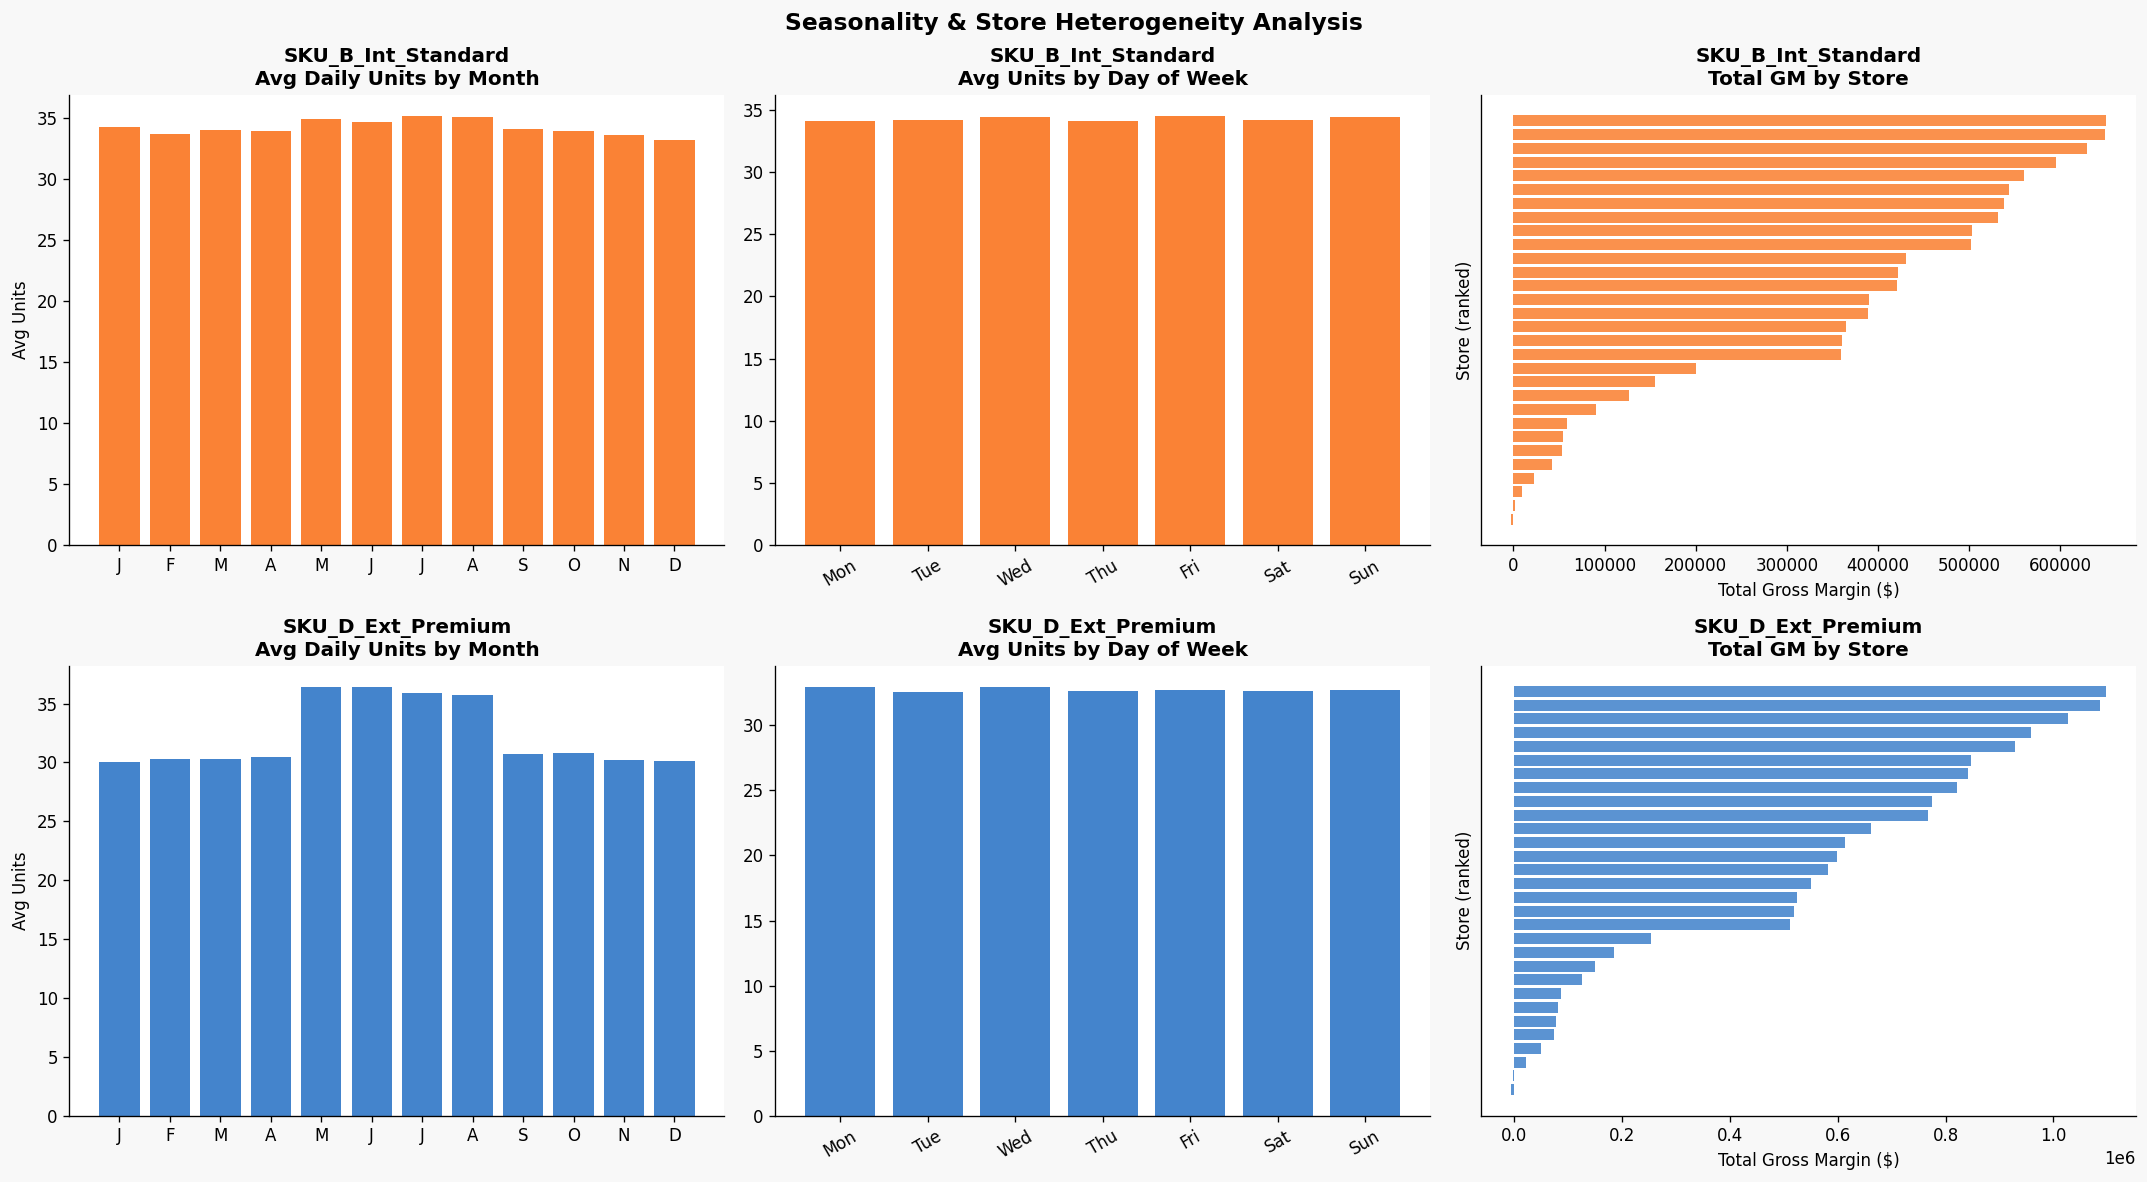

<Figure size 768x576 with 0 Axes>

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Seasonality & Store Heterogeneity Analysis', fontsize=14, fontweight='bold')

# exclude zero scale only
for col, (sku, color) in enumerate(zip(TARGET_SKUS, [HD_ORANGE, BLUE])):
    sub = df[
        (df['sku'] == sku) &
        (~df['zero_sale'])
    ].copy()
    
    # Monthly seasonality
    monthly_sku = sub.groupby('month')['sales_units'].mean()
    axes[col, 0].bar(monthly_sku.index, monthly_sku.values, color=color, alpha=0.8)
    axes[col, 0].set_title(f'{sku}\nAvg Daily Units by Month')
    axes[col, 0].set_xticks(range(1,13))
    axes[col, 0].set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
    axes[col, 0].set_ylabel('Avg Units')

    # Day-of-week
    dow_sku = sub.groupby('dayofweek')['sales_units'].mean()
    axes[col, 1].bar(dow_sku.index, dow_sku.values, color=color, alpha=0.8)
    axes[col, 1].set_title(f'{sku}\nAvg Units by Day of Week')
    axes[col, 1].set_xticks(range(7))
    axes[col, 1].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], rotation=30)

    # Store-level distribution
    store_margin = sub.groupby('store_id')['gross_margin'].sum().sort_values()
    axes[col, 2].barh(range(len(store_margin)), store_margin.values, color=color, alpha=0.7)
    axes[col, 2].set_title(f'{sku}\nTotal GM by Store')
    axes[col, 2].set_xlabel('Total Gross Margin ($)')
    axes[col, 2].set_ylabel('Store (ranked)')
    axes[col, 2].set_yticks([])

    
plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

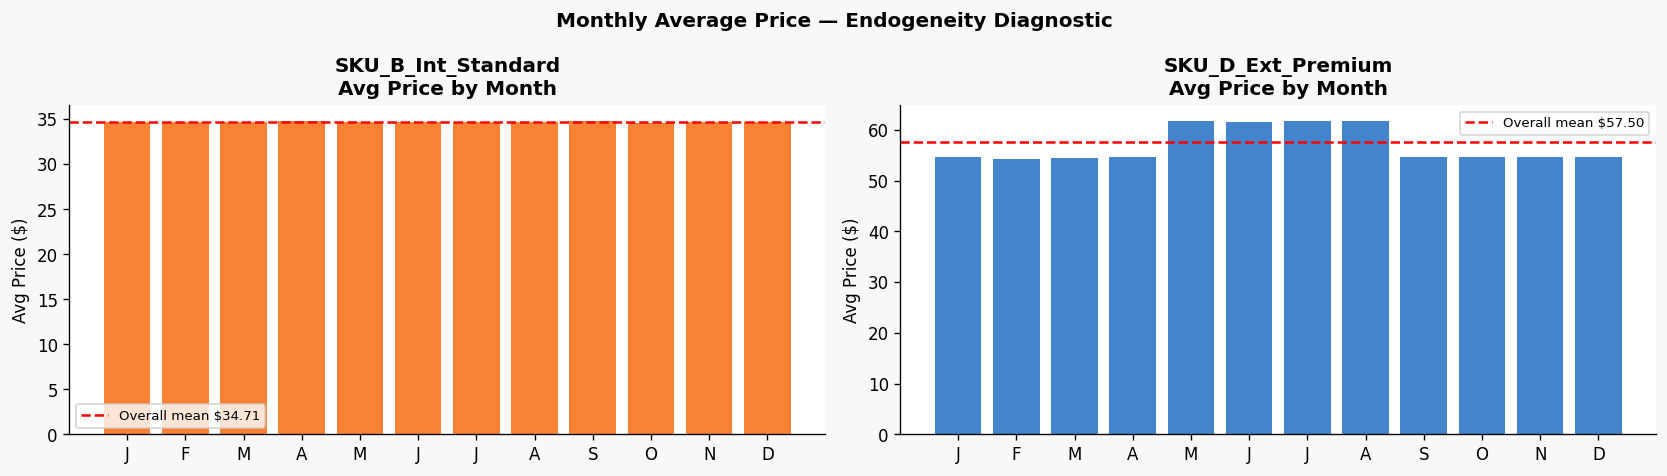

In [17]:
# Monthly average price
monthly_price = sub.groupby('month')['price'].mean()

fig2, ax_price = plt.subplots(1, 2, figsize=(14, 4))
fig2.suptitle('Monthly Average Price — Endogeneity Diagnostic',
              fontsize=12, fontweight='bold')

for i, (sku, color) in enumerate(zip(TARGET_SKUS, [HD_ORANGE, BLUE])):
    sub_p = df[(df['sku']==sku) & (~df['zero_sale'])].copy()
    monthly_price = sub_p.groupby('month')['price'].mean()
    ax_price[i].bar(monthly_price.index, monthly_price.values,
                    color=color, alpha=0.8)
    ax_price[i].set_title(f'{sku}\nAvg Price by Month')
    ax_price[i].set_xticks(range(1,13))
    ax_price[i].set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
    ax_price[i].set_ylabel('Avg Price ($)')
    
    overall = sub_p['price'].mean()
    ax_price[i].axhline(overall, color='red', linestyle='--',
                        linewidth=1.5, label=f'Overall mean ${overall:.2f}')
    ax_price[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [18]:
# Store clustering
print('\n ** Store Revenue Quartiles (used for segmented analysis):')
store_rev = df.groupby('store_id')['revenue'].sum()
df['store_quartile'] = df['store_id'].map(
    pd.qcut(store_rev, q=4, labels=['Q1_Low','Q2_MidLow','Q3_MidHigh','Q4_High'])
)
print(df.groupby('store_quartile')['store_id'].nunique().to_string())


 ** Store Revenue Quartiles (used for segmented analysis):
store_quartile
Q1_Low        8
Q2_MidLow     7
Q3_MidHigh    7
Q4_High       8


## Elasticity Baseline: OLS Log-Log 

Before using machine learning, I fit a classical log-log demand model to 
get an interpretable elasticity estimate. This gives a theoretical benchmark 
and answers the question: for every 1% price increase, how much does demand drop?

The model has limitations: only 4 unique prices for SKU B, low R²; but 
these limitations themselves are informative and motivate the XGBoost approach.

Model: ln(units) = α + ε·ln(price) + seasonal + quarter + ln(inv)

In [19]:
OLS_FEATURES = ['ln_price','seasonal_sin','seasonal_cos','q2','q3','q4','ln_inv']

ols_results = {}

for sku in TARGET_SKUS:
    print(f'\n  ** {sku}')
    
    sub = df[
    (df['sku']==sku) &
    (~df['zero_sale']) &
    (~df['likely_stockout'].astype(bool))
    ].copy()
    
    sub['q2'] = (sub['quarter']==2).astype(int)
    sub['q3'] = (sub['quarter']==3).astype(int)
    sub['q4'] = (sub['quarter']==4).astype(int)
    sub = sub.dropna(subset=OLS_FEATURES + ['ln_units'])

    X = sm.add_constant(sub[OLS_FEATURES])
    y = sub['ln_units']

    model = sm.OLS(y, X).fit(cov_type='HC3')
    print(model.summary())

    ##########################################################

    # CV R²
    lr = LinearRegression()
    cv = cross_val_score(lr, sub[OLS_FEATURES], y,
                         cv=KFold(5, shuffle=True, random_state=42), scoring='r2')
    print(f'  CV R²: {cv.mean():.3f} ± {cv.std():.3f}')

    ##########################################################

    # VIF
    vif = pd.DataFrame({
        'feature': OLS_FEATURES,
        'VIF'    : [variance_inflation_factor(X.values, i+1) for i in range(len(OLS_FEATURES))]
    })
    print(f'\n  VIF table:\n{vif.to_string(index=False)}')

    ##########################################################
    
    eps    = model.params['ln_price']
    ci     = model.conf_int().loc['ln_price'].values
    c      = sub['unit_cost'].mode()[0]

    ols_results[sku] = {
        'model': model, 'data': sub, 'elasticity': eps,
        'ci': ci, 'r2': model.rsquared, 'unit_cost': c,
        'cv_r2': cv.mean()
    }

    print(f'\n  -> Elasticity: {eps:.3f}  95%CI [{ci[0]:.3f}, {ci[1]:.3f}]')
    print(f'    R²: {model.rsquared:.3f}  |  CV R²: {cv.mean():.3f}')
    if model.rsquared < 0.15:
        print('    Low R² — limited price variation in data, OLS elasticity unreliable alone')
    if eps > -1:
        print('    Inelastic demand (ε > -1) — Lerner rule hits ceiling; use ML model instead')

    
    if sku == 'SKU_D_Ext_Premium':
        print()
        print('  !!! ENDOGENEITY WARNING:')
        print('  Seasonal price audit shows SKU D prices are')
        print('  12.2% higher in summer than fall/winter. Summer is also')
        print('  peak demand season for exterior paint.')
        print('  This positive correlation biases OLS elasticity toward zero.')
        print('  True elasticity is likely more negative than -0.640.')
            
    print('#' * 80)
##########################################################


  ** SKU_B_Int_Standard
                            OLS Regression Results                            
Dep. Variable:               ln_units   R-squared:                       0.070
Model:                            OLS   Adj. R-squared:                  0.069
Method:                 Least Squares   F-statistic:                     202.0
Date:                Wed, 01 Apr 2026   Prob (F-statistic):          3.33e-289
Time:                        19:37:38   Log-Likelihood:                -23041.
No. Observations:               17021   AIC:                         4.610e+04
Df Residuals:                   17013   BIC:                         4.616e+04
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.9131

## Elasticity Second Baseline: SEMI-LOG

Model: ln(units) = α + b·price + seasonal + quarter + ln(inv)

ln(units) ~ price  (not ln(price))

Key difference: elasticity is NOT constant — it increases with price

This allows for a natural interior optimum on the margin curve

Formula: GM(p) = (p-c) × exp(a + b·p)  →  dGM/dp = 0  →  p* = c - 1/b

In [20]:
SEMILOG_FEATURES = ['price', 'seasonal_sin', 'seasonal_cos',
                    'q2', 'q3', 'q4', 'ln_inv']

for sku in TARGET_SKUS:
    print(f'\n  ** {sku}')

    sub = df[
    (df['sku']==sku) &
    (~df['zero_sale']) &
    (~df['likely_stockout'].astype(bool))    
    ].copy()
    
    sub['q2'] = (sub['quarter'] == 2).astype(int)
    sub['q3'] = (sub['quarter'] == 3).astype(int)
    sub['q4'] = (sub['quarter'] == 4).astype(int)
    sub = sub.dropna(subset=SEMILOG_FEATURES + ['ln_units'])

    X_sl = sm.add_constant(sub[SEMILOG_FEATURES])
    y_sl = sub['ln_units']

    model_sl = sm.OLS(y_sl, X_sl).fit(cov_type='HC3')

    b_price = model_sl.params['price']   # semi-log price coefficient
    cur_p   = sub['price'].mean() #current_price
    c       = sub['unit_cost'].mode()[0] 

    semi_elas_at_mean = b_price * cur_p
    log_log_elas = ols_results[sku]['elasticity']

    print(f'  Semi-log price coefficient      : {b_price:.4f}')
    print(f'  Elasticity at current ${cur_p:.2f}    : {semi_elas_at_mean:.3f}')
    print(f'  (Log-log constant elasticity    : {log_log_elas:.3f})')
    print(f'  R²                              : {model_sl.rsquared:.3f}')
    print(f'  (Log-log R²                     : {ols_results[sku]["r2"]:.3f})')


    
    # Analytical optimum
    # Derivation:
    #   GM(p) = (p - c) × exp(α + b·p + controls)
    #   Let K = exp(α + controls) — constant w.r.t. price
    #   GM(p) = K × (p - c) × exp(b·p)
    #   dGM/dp = K × [exp(b·p) + (p-c) × b × exp(b·p)]
    #          = K × exp(b·p) × [1 + b(p-c)]
    #   Set to zero: 1 + b(p-c) = 0  →  p* = c - 1/b
    p_opt_semilog = c - 1 / b_price

    # Lower: cost + 5% margin floor
    # Upper: 25% above observed historical maximum
    observed_max = df[df['sku'] == sku]['price'].max()
    p_lo_check   = c * 1.05
    p_hi_check   = observed_max * 1.25

    print(f'\n  Analytical optimum (semi-log)   : ${p_opt_semilog:.2f}')
    print(f'  Analytical optimum (log-log)    : '
          f'{"Inelastic — no interior solution" if log_log_elas > -1 else f"${c * log_log_elas / (log_log_elas + 1):.2f}"}')
    print(f'  Defensible price bounds         : ${p_lo_check:.2f} – ${p_hi_check:.2f}')

    if p_lo_check < p_opt_semilog < p_hi_check:
        print(f'    Semi-log finds interior optimum within price bounds')
        print(f'    This gives a principled optimal price without a ceiling assumption')
    else:
        location = 'above ceiling' if p_opt_semilog > p_hi_check else 'below floor'
        print(f'    Semi-log optimum ${p_opt_semilog:.2f} is {location}')
        print(f'    Demand is inelastic throughout the defensible price range')
        print(f'    under BOTH log-log and semi-log specifications.')
        print(f'    Both models agree: direction is to raise price toward ceiling.')
        print(f'    This convergence strengthens confidence in the recommendation.')

############################################################################
    # Model comparison summary
    print(f'\n  Specification comparison:')
    print(f'  {"":30} {"Log-Log":>12} {"Semi-Log":>12}')
    print(f'  {"─"*54}')
    print(f'  {"Elasticity at current price":30} '
          f'{log_log_elas:>12.3f} {semi_elas_at_mean:>12.3f}')
    print(f'  {"R²":30} '
          f'{ols_results[sku]["r2"]:>12.3f} {model_sl.rsquared:>12.3f}')

    if log_log_elas < -1:
        p_opt_loglog = c * log_log_elas / (log_log_elas + 1)
        loglog_opt_str = f'${p_opt_loglog:.2f}'
    else:
        loglog_opt_str = 'hits ceiling'
    
    print(f'  {"Analytical optimum":30} '
          f'{loglog_opt_str:>12} ${p_opt_semilog:>11.2f}')

    print(f'  {"Assumption":30} '
          f'{"const. ε":>12} {"ε grows w/ p":>12}')


  ** SKU_B_Int_Standard
  Semi-log price coefficient      : -0.0138
  Elasticity at current $34.91    : -0.481
  (Log-log constant elasticity    : -0.341)
  R²                              : 0.070
  (Log-log R²                     : 0.070)

  Analytical optimum (semi-log)   : $94.65
  Analytical optimum (log-log)    : Inelastic — no interior solution
  Defensible price bounds         : $23.10 – $43.75
    Semi-log optimum $94.65 is above ceiling
    Demand is inelastic throughout the defensible price range
    under BOTH log-log and semi-log specifications.
    Both models agree: direction is to raise price toward ceiling.
    This convergence strengthens confidence in the recommendation.

  Specification comparison:
                                      Log-Log     Semi-Log
  ──────────────────────────────────────────────────────
  Elasticity at current price          -0.341       -0.481
  R²                                    0.070        0.070
  Analytical optimum             hits 

## XGBoost Demand Model

Why XGBoost?

• Handles discrete price tiers (no linearity assumption)

• Captures interactions: price × season, price × store

• More robust when price variation is limited

• Directly optimisable via grid search over price



The OLS baseline and quasi-experiment are presented sequentially for narrative clarity. Analytically, the OLS findings inform why XGBoost is needed: low R² (7%), limited price variation for SKU B, and potential endogeneity for SKU D all motivate a more flexible approach. 

The segmented analysis later confirms the store heterogeneity that explains XGBoost's high feature importance for store_enc.

In [21]:
le_store = LabelEncoder()
le_sku   = LabelEncoder()
df['store_enc'] = le_store.fit_transform(df['store_id'])
df['sku_enc']   = le_sku.fit_transform(df['sku'])

ML_FEATURES = [
    'price', 'unit_cost', 'price_to_cost', 'beginning_inventory',
    'month', 'quarter', 'dayofweek', 'seasonal_sin', 'seasonal_cos',
    'store_enc', 'sku_enc', 'year'
]

xgb_results = {}

for sku in TARGET_SKUS:
    print(f'\n  ** {sku}')
    
    sub = df[
    (df['sku']==sku) &
    (~df['zero_sale']) &
    (~df['likely_stockout'].astype(bool))
    ].copy()
    
    print(f'  Clean rows (exclude. zero-sale + likely-stockout): {len(sub):,}')
    
    sub = sub.dropna(subset=ML_FEATURES + ['sales_units'])

    X = sub[ML_FEATURES].values
    y = sub['sales_units'].values

    # Random 80/20 split
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

    model = xgb.XGBRegressor(
            n_estimators=400, max_depth=5, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, min_child_weight=10,
            random_state=42, verbosity=0
        )

    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    r2   = r2_score(y_te, y_pred)
    mae  = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))

    # 5-fold CV
    cv_r2 = cross_val_score(model, X, y,
                            cv=KFold(5, shuffle=True, random_state=42),
                            scoring='r2')

    print(f'  Random split Test R²  : {r2:.3f}')
    print(f'  Test MAE              : {mae:.2f} units')
    print(f'  Test RMSE             : {rmse:.2f} units')
    print(f'  CV R²                 : {cv_r2.mean():.3f} ± {cv_r2.std():.3f}')

    ##########################################################
    # Time-based validation (no data leakage)
    # Train on 2021-2022, test on 2023
    # This confirms the model generalises to future periods
    cutoff     = pd.Timestamp('2023-01-01')
    train_mask = sub['date'] < cutoff
    test_mask  = sub['date'] >= cutoff

    X_time_tr = sub[train_mask][ML_FEATURES].values
    y_time_tr = sub[train_mask]['sales_units'].values
    X_time_te = sub[test_mask][ML_FEATURES].values
    y_time_te = sub[test_mask]['sales_units'].values

    r2_time  = None
    mae_time = None
    
    if len(X_time_te) > 0:
        m_time = xgb.XGBRegressor(
            n_estimators=400, max_depth=5, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, min_child_weight=10,
            random_state=42, verbosity=0)

        m_time.fit(X_time_tr, y_time_tr)
        y_time_pred = m_time.predict(X_time_te)
        r2_time  = r2_score(y_time_te, y_time_pred)
        mae_time = mean_absolute_error(y_time_te, y_time_pred)

        print(f'\n  Time-based validation (train < 2023, test >= 2023):')
        print(f'  Train rows : {len(X_time_tr):,}  |  Test rows: {len(X_time_te):,}')
        print(f'  Time R²    : {r2_time:.3f}')
        print(f'  Time MAE   : {mae_time:.2f} units')

        degradation = (r2 - r2_time) / r2 * 100
        if degradation < 15:
            print(f'  Time R² within {degradation:.1f}% of random split — no significant leakage')
        else:
            print(f'  Time R² drops {degradation:.1f}% vs random split — possible temporal drift')
    else:
        print(f'\n  No test rows after 2023-01-01 — time-based validation skipped')
        
    ##########################################################
    
    # Feature importance 
    imp = pd.Series(model.feature_importances_,
                    index=ML_FEATURES).sort_values(ascending=False)
    print(f'\n  Top 5 features:')
    print(imp.head(5).round(4).to_string())

    xgb_results[sku] = {
        'model'    : model, 'data': sub, 'features': ML_FEATURES,
        'r2'       : r2,    'mae': mae,  'cv_r2': cv_r2.mean(),
        'r2_time'  : r2_time if len(X_time_te) > 0 else None,
        'unit_cost': sub['unit_cost'].mode()[0],
        'importance': imp
    }

print('\n XGBoost models trained')


  ** SKU_B_Int_Standard
  Clean rows (exclude. zero-sale + likely-stockout): 17,021
  Random split Test R²  : 0.858
  Test MAE              : 5.54 units
  Test RMSE             : 7.19 units
  CV R²                 : 0.861 ± 0.004

  Time-based validation (train < 2023, test >= 2023):
  Train rows : 13,817  |  Test rows: 3,204
  Time R²    : 0.865
  Time MAE   : 5.51 units
  Time R² within -0.8% of random split — no significant leakage

  Top 5 features:
store_enc              0.7292
beginning_inventory    0.1330
price                  0.0287
price_to_cost          0.0213
seasonal_cos           0.0210

  ** SKU_D_Ext_Premium
  Clean rows (exclude. zero-sale + likely-stockout): 15,997
  Random split Test R²  : 0.920
  Test MAE              : 3.98 units
  Test RMSE             : 4.97 units
  CV R²                 : 0.918 ± 0.002

  Time-based validation (train < 2023, test >= 2023):
  Train rows : 12,994  |  Test rows: 3,003
  Time R²    : 0.912
  Time MAE   : 4.08 units
  Time R² within

## XGBoost Feature Importance & Price Sweep

Price bounds

Rule: restrict optimisation to within 25% of observed historical maximum to avoid extrapolating beyond data support

Lower bound: cost × 1.05  (minimum 5% gross margin floor)

Upper bound: observed_max × 1.25

   SKU B: $35.00 × 1.25 = $43.75 → $44.00
   
   SKU D: $62.00 × 1.25 = $77.50 → $78.00

SKU B ceiling also keeps Standard below Premium mean ($49.76) — respects product hierarchy

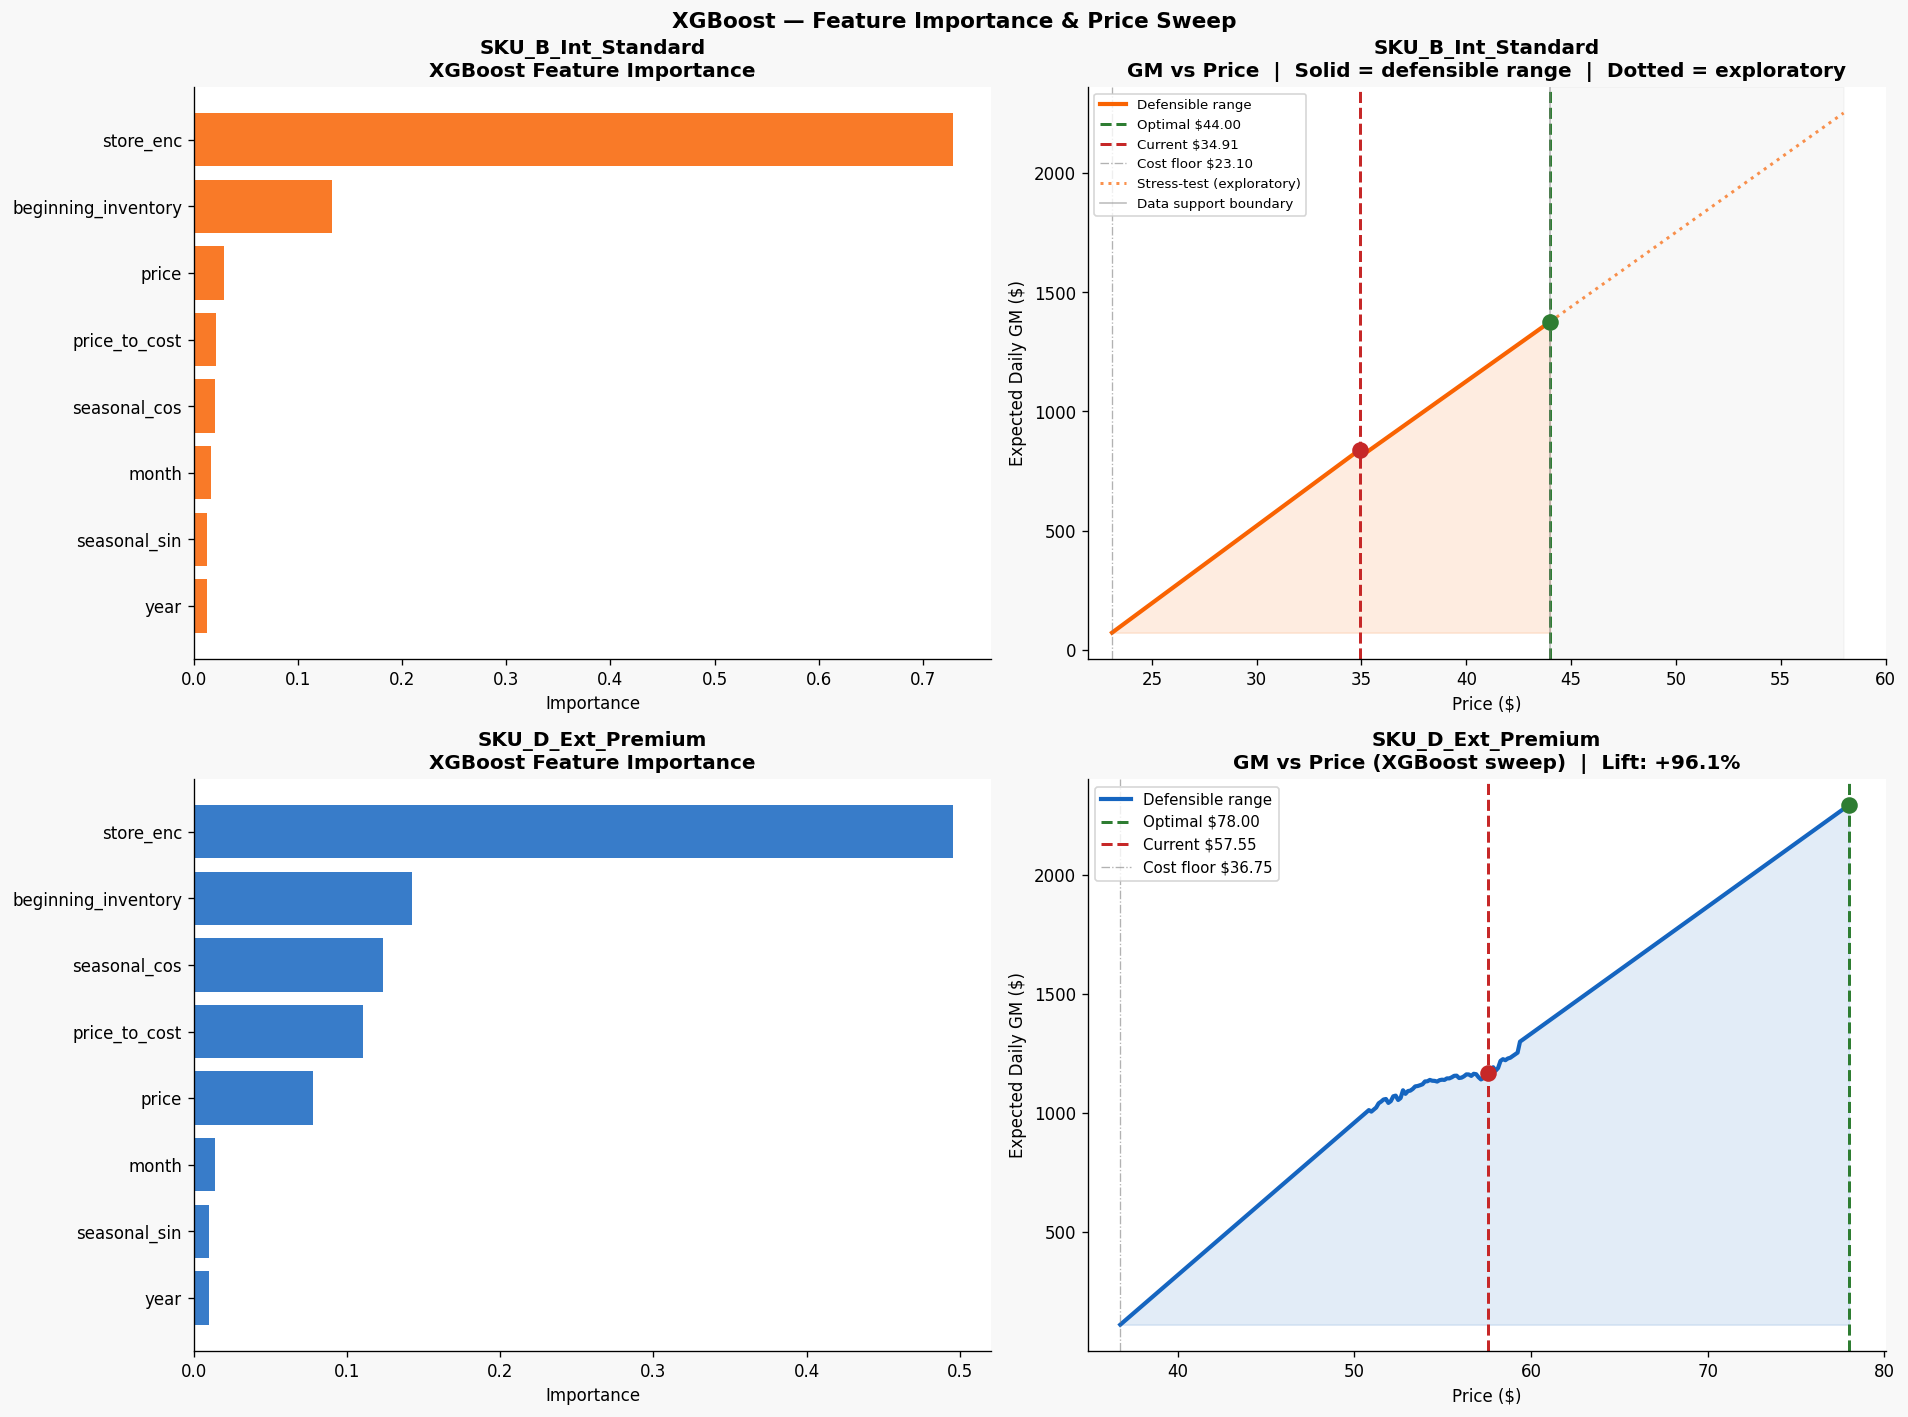

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('XGBoost — Feature Importance & Price Sweep', fontsize=13, fontweight='bold')

price_bounds = {
    'SKU_B_Int_Standard': (22.0 * 1.05, 44.0),   # 25% above observed max $35
    'SKU_D_Ext_Premium' : (35.0 * 1.05, 78.0),   # 25% above observed max $62
}

sweep_results = {}

for row, (sku, res) in enumerate(xgb_results.items()):
    color = HD_ORANGE if row == 0 else BLUE
    c = res['unit_cost']
    sub = res['data']
    model = res['model']
    feats = res['features']
    p_lo, p_hi = price_bounds[sku]

    # Feature importance plot
    imp = res['importance'].head(8)
    axes[row, 0].barh(imp.index[::-1], imp.values[::-1], color=color, alpha=0.85)
    axes[row, 0].set_title(f'{sku}\nXGBoost Feature Importance')
    axes[row, 0].set_xlabel('Importance')

    # Price sweep — hold all features at mean, vary price
    X_mean     = sub[feats].mean().copy()
    price_grid = np.linspace(p_lo, p_hi, 300)
    margins, units_pred = [], []

    for p in price_grid:
        row_vals = X_mean.copy()
        row_vals['price']         = p
        row_vals['price_to_cost'] = p / c
        q  = max(0, model.predict(row_vals.values.reshape(1, -1))[0])
        gm = (p - c) * q
        margins.append(gm)
        units_pred.append(q)

    margins = np.array(margins)
    units_pred = np.array(units_pred)
    p_opt = price_grid[np.argmax(margins)]
    mg_opt = margins.max()
    cur_price  = sub['price'].mean()
    idx_cur = np.argmin(np.abs(price_grid - cur_price))
    mg_cur = margins[idx_cur]

    sweep_results[sku] = {
        'p_opt'        : p_opt,
        'mg_opt'       : mg_opt,
        'mg_cur'       : mg_cur,
        'price_grid'   : price_grid,
        'margins'      : margins,
        'units'        : units_pred,
        'current_price': cur_price,
        'unit_cost'    : c,
        'lift_pct'     : (mg_opt - mg_cur) / mg_cur * 100
    }

    axes[row, 1].plot(price_grid, margins,
                      color=color, linewidth=2.5, label='Defensible range')
    axes[row, 1].fill_between(price_grid, margins[0], margins,
                          alpha=0.12, color=color)
    axes[row, 1].axvline(p_opt,     color=GREEN, linestyle='--', linewidth=1.8,
                         label=f'Optimal ${p_opt:.2f}')
    axes[row, 1].axvline(cur_price, color=RED,   linestyle='--', linewidth=1.8,
                         label=f'Current ${cur_price:.2f}')
    axes[row, 1].scatter([p_opt],    [mg_opt], s=80, color=GREEN, zorder=5)
    axes[row, 1].scatter([cur_price],[mg_cur],  s=80, color=RED,   zorder=5)
    axes[row, 1].set_xlabel('Price ($)')
    axes[row, 1].set_ylabel('Expected Daily GM ($)')

    
    if row == 0:  
        axes[row, 1].set_xlim(left=p_lo * 0.95, right=60)
    else:         
        axes[row, 1].set_xlim(left=p_lo * 0.95)


    axes[row, 1].axvline(p_lo, color='gray', linewidth=0.8, linestyle='-.',
                         alpha=0.6, label=f'Cost floor ${p_lo:.2f}')

# Stress-test sweep for SKU B only ($44–$58)
sku_b   = 'SKU_B_Int_Standard'
res_b   = xgb_results[sku_b]
c_b     = res_b['unit_cost']
sub_b   = res_b['data']
model_b = res_b['model']
feats_b = res_b['features']

X_mean_b    = sub_b[feats_b].mean().copy()
stress_grid = np.linspace(44.0, 58.0, 100)
stress_margins = []

for p in stress_grid:
    row_vals = X_mean_b.copy()
    row_vals['price']         = p
    row_vals['price_to_cost'] = p / c_b
    q  = max(0, model_b.predict(row_vals.values.reshape(1, -1))[0])
    stress_margins.append((p - c_b) * q)

stress_margins = np.array(stress_margins)

# Add stress-test to SKU B chart
axes[0, 1].plot(stress_grid, stress_margins,
                color=HD_ORANGE, linewidth=1.8, linestyle=':',
                alpha=0.7, label='Stress-test (exploratory)')
axes[0, 1].axvspan(44.0, 58.0, alpha=0.05, color='gray')
axes[0, 1].axvline(44.0, color='gray', linewidth=1.0, linestyle='-', alpha=0.5,
                   label='Data support boundary')
axes[0, 1].set_title(
    'SKU_B_Int_Standard\n'
    'GM vs Price  |  Solid = defensible range  |  Dotted = exploratory'
)
axes[0, 1].legend(fontsize=8)

# Title for SKU D
s_d = sweep_results['SKU_D_Ext_Premium']
axes[1, 1].set_title(
    f'SKU_D_Ext_Premium\n'
    f'GM vs Price (XGBoost sweep)  |  Lift: {s_d["lift_pct"]:+.1f}%'
)
axes[1, 1].legend(fontsize=9)

fig.savefig('Feature Importance & Price Sweep', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.tight_layout()
plt.show()

In [23]:
# Summary table
print('\n ** XGBoost Price Sweep Summary:')
print(f'  {"SKU":<22} {"Cost":>6} {"Current":>9} {"Optimal":>9} '
      f'{"Δ Price":>9} {"GM Lift%":>9}')
print('  ' + '─'*66)
for sku, s in sweep_results.items():
    print(f'  {sku:<22} ${s["unit_cost"]:>5.2f} ${s["current_price"]:>8.2f} '
          f'${s["p_opt"]:>8.2f} ${s["p_opt"]-s["current_price"]:>+8.2f} '
          f'{s["lift_pct"]:>+8.1f}%')

print()
print('  ** Interpretation:')
print('  Optimal prices hit the defensible ceiling — the model consistently')
print('  recommends pricing as high as the data-supported range allows.')
print('  The stress-test dotted line for SKU B shows margin continues rising')
print('  beyond $44, but we do not recommend acting on this without A/B validation.')
print()
print('  Price bounds reflect where model predictions are data-supported:')
for sku, (lo, hi) in price_bounds.items():
    c = xgb_results[sku]['unit_cost']
    obs_max = hi / 1.25 if 'B' in sku else hi / 1.26
    print(f'  {sku}: floor=${lo:.2f} (cost+5%)  '
          f'ceiling=${hi:.2f} (25% above observed max ~${obs_max:.0f})')


 ** XGBoost Price Sweep Summary:
  SKU                      Cost   Current   Optimal   Δ Price  GM Lift%
  ──────────────────────────────────────────────────────────────────
  SKU_B_Int_Standard     $22.00 $   34.91 $   44.00 $   +9.09    +64.0%
  SKU_D_Ext_Premium      $35.00 $   57.55 $   78.00 $  +20.45    +96.1%

  ** Interpretation:
  Optimal prices hit the defensible ceiling — the model consistently
  recommends pricing as high as the data-supported range allows.
  The stress-test dotted line for SKU B shows margin continues rising
  beyond $44, but we do not recommend acting on this without A/B validation.

  Price bounds reflect where model predictions are data-supported:
  SKU_B_Int_Standard: floor=$23.10 (cost+5%)  ceiling=$44.00 (25% above observed max ~$35)
  SKU_D_Ext_Premium: floor=$36.75 (cost+5%)  ceiling=$78.00 (25% above observed max ~$62)


## Retrospective Quasi-Experiment

Idea: On days where different stores charge different prices

for the same SKU, we have a natural experiment

Treatment = above-median price | Control = below-median price

This gives a more causally credible demand effect than OLS alone.




In [24]:
quasi_results = {}

for sku in TARGET_SKUS:
    print(f'\n  ** {sku}')
    sub = df[
    (df['sku']==sku) &
    (~df['zero_sale'])   
    ].copy()

    # Find dates with meaningful cross-store price variation
    date_price_std = sub.groupby('date')['price'].std()
    variable_dates = date_price_std[date_price_std > 0.5].index
    sub_var = sub[sub['date'].isin(variable_dates)].copy()

    print(f'  Total non-zero rows      : {len(sub):,}')
    print(f'  Dates with price variation: {len(variable_dates):,}')
    print(f'  Rows in quasi-experiment : {len(sub_var):,}')

    if len(sub_var) < 100:
        print('    Insufficient price variation for quasi-experiment')
        print('    This confirms prices are set centrally — a key data limitation')
        quasi_results[sku] = {'insufficient_data': True}
        continue

    # Split: above vs below median price on each date
    sub_var['date_median_price'] = sub_var.groupby('date')['price'].transform('median')
    sub_var['high_price'] = sub_var['price'] >= sub_var['date_median_price']
    
    high = sub_var[sub_var['high_price']]['sales_units']
    low  = sub_var[~sub_var['high_price']]['sales_units']
    
    # If either group is empty, this SKU can't support a quasi-experiment
    if len(high) == 0 or len(low) == 0:
        print(f'     Cannot split into high/low groups — SKU B has only 4 unique')
        print(f'     prices. On variable dates, all stores fall on the same side')
        print(f'     of the median. This confirms SKU B has never been properly')
        print(f'     price-tested. Quasi-experiment skipped for this SKU.')
        quasi_results[sku] = {'insufficient_data': True,
                              'reason': 'only_4_unique_prices'}
        continue

    # Statistical tests. 
    #answering to this question: is the difference in units sold between high-price and low-price stores statistically real,
    #or could it be random chance?
    t_stat, t_pval  = ttest_ind(high, low)
    u_stat, u_pval  = mannwhitneyu(high, low, alternative='two-sided')
    effect_size     = (low.mean() - high.mean()) / sub_var['sales_units'].std()

    print(f'\n  High-price group  — mean units: {high.mean():.1f}  n={len(high):,}')
    print(f'  Low-price group   — mean units: {low.mean():.1f}  n={len(low):,}')
    print(f'  Difference        : {high.mean()-low.mean():+.1f} units')
    print(f'  T-test p-value    : {t_pval:.4f}  {"significant" if t_pval<0.05 else "not significant"}')
    print(f'  Mann-Whitney p    : {u_pval:.4f}  {"significant" if u_pval<0.05 else "not significant"}')
    print(f'  Cohen\'s d         : {effect_size:.3f}')

    # Quasi-elasticity estimate
    avg_high_price = sub_var[sub_var['high_price']]['price'].mean()
    avg_low_price  = sub_var[~sub_var['high_price']]['price'].mean()
    pct_price_diff = (avg_high_price - avg_low_price) / avg_low_price
    pct_unit_diff  = (high.mean() - low.mean()) / low.mean()
    quasi_elas     = pct_unit_diff / pct_price_diff if pct_price_diff != 0 else np.nan

    print(f'\n  Avg high price    : ${avg_high_price:.2f}')
    print(f'  Avg low  price    : ${avg_low_price:.2f}')
    print(f'  Implied quasi-elasticity: {quasi_elas:.3f}')
    print(f'  (Compare to OLS elasticity: {ols_results[sku]["elasticity"]:.3f})')

    quasi_results[sku] = {
        'n_variable_dates': len(variable_dates),
        'mean_high': high.mean(), 'mean_low': low.mean(),
        't_pval': t_pval, 'u_pval': u_pval,
        'quasi_elasticity': quasi_elas,
        'effect_size': effect_size
    }


  ** SKU_B_Int_Standard
  Total non-zero rows      : 22,446
  Dates with price variation: 197
  Rows in quasi-experiment : 4,908

  High-price group  — mean units: 34.3  n=4,369
  Low-price group   — mean units: 40.9  n=539
  Difference        : -6.6 units
  T-test p-value    : 0.0000  significant
  Mann-Whitney p    : 0.0000  significant
  Cohen's d         : 0.338

  Avg high price    : $35.00
  Avg low  price    : $25.15
  Implied quasi-elasticity: -0.410
  (Compare to OLS elasticity: -0.341)

  ** SKU_D_Ext_Premium
  Total non-zero rows      : 20,157
  Dates with price variation: 648
  Rows in quasi-experiment : 13,083

  High-price group  — mean units: 30.0  n=7,282
  Low-price group   — mean units: 32.3  n=5,801
  Difference        : -2.3 units
  T-test p-value    : 0.0000  significant
  Mann-Whitney p    : 0.0000  significant
  Cohen's d         : 0.145

  Avg high price    : $57.01
  Avg low  price    : $52.61
  Implied quasi-elasticity: -0.866
  (Compare to OLS elasticity: -0

## Segmented Elasticity Analysis

Does price sensitivity vary by season or store tier?


In [25]:
def quick_elasticity(data, label=''):
    """Fit log-log OLS on a subset and return elasticity + CI."""
    d = data.dropna(subset=['ln_units','ln_price','ln_inv'])
    if len(d) < 50:
        return None
    X = sm.add_constant(d[['ln_price','ln_inv','seasonal_sin','seasonal_cos']])
    m = sm.OLS(d['ln_units'], X).fit(cov_type='HC3')
    eps = m.params['ln_price']
    ci  = m.conf_int().loc['ln_price'].values
    return {'label': label, 'elasticity': eps, 'ci': ci,
            'n': len(d), 'r2': m.rsquared}

seg_results = {}

for sku in TARGET_SKUS:
    print(f'\n  ** {sku}')
    sub = df[
    (df['sku']==sku) &
    (~df['zero_sale'])
    ].copy()

    
    sub['q2'] = (sub['quarter']==2).astype(int)
    sub['q3'] = (sub['quarter']==3).astype(int)
    sub['q4'] = (sub['quarter']==4).astype(int)

    segs = []

    for season, months in [('Winter (Nov-Feb)', [11,12,1,2]),
                            ('Spring (Mar-May)', [3,4,5]),
                            ('Summer (Jun-Aug)', [6,7,8]),
                            ('Fall   (Sep-Oct)', [9,10])]:
        s_data = sub[sub['month'].isin(months)]
        r = quick_elasticity(s_data, f'Season: {season}')
        if r: segs.append(r)

    # By store quartile
    for q in ['Q1_Low','Q2_MidLow','Q3_MidHigh','Q4_High']:
        s_data = sub[sub['store_quartile']==q]
        r = quick_elasticity(s_data, f'Store: {q}')
        if r: segs.append(r)

    r_all = quick_elasticity(sub, 'Overall')
    if r_all: segs.append(r_all)

    seg_results[sku] = segs

    print(f'  {"Segment":<30} {"Elasticity":>11} {"95% CI":>22} {"N":>7}')
    print('  ' + '─'*72)
    for s in segs:
        print(f'  {s["label"]:<30} {s["elasticity"]:>11.3f} '
              f'[{s["ci"][0]:>7.3f}, {s["ci"][1]:>7.3f}] {s["n"]:>7,}')



  ** SKU_B_Int_Standard
  Segment                         Elasticity                 95% CI       N
  ────────────────────────────────────────────────────────────────────────
  Season: Winter (Nov-Feb)            -0.346 [ -0.374,  -0.317]   7,302
  Season: Spring (Mar-May)            -0.328 [ -0.365,  -0.291]   6,863
  Season: Summer (Jun-Aug)            -0.354 [ -0.388,  -0.321]   5,303
  Season: Fall   (Sep-Oct)            -0.331 [ -0.379,  -0.282]   2,978
  Store: Q1_Low                       -1.052 [ -1.115,  -0.989]   2,999
  Store: Q2_MidLow                    -0.539 [ -0.584,  -0.493]   5,969
  Store: Q3_MidHigh                   -0.200 [ -0.232,  -0.167]   6,290
  Store: Q4_High                      -0.055 [ -0.070,  -0.040]   7,188
  Overall                             -0.342 [ -0.359,  -0.324]  22,446

  ** SKU_D_Ext_Premium
  Segment                         Elasticity                 95% CI       N
  ────────────────────────────────────────────────────────────────────────
 

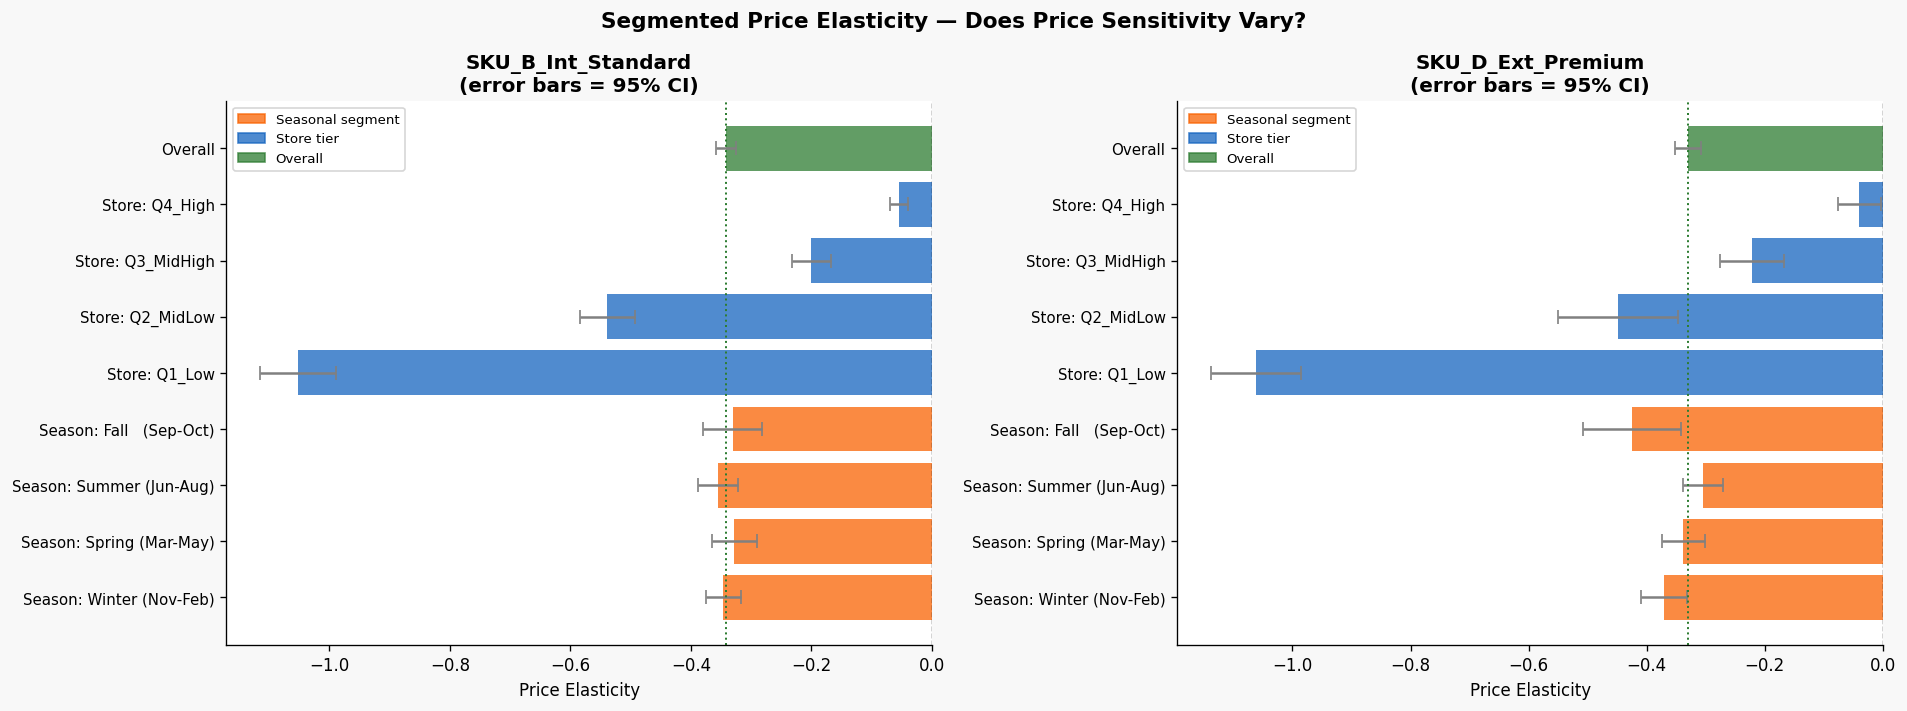

In [26]:
# Visualise segmented elasticity
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Segmented Price Elasticity — Does Price Sensitivity Vary?',
             fontsize=13, fontweight='bold')

for ax, (sku, segs) in zip(axes, seg_results.items()):
    labels = [s['label'] for s in segs]
    elas = [s['elasticity'] for s in segs]
    ci_lo = [s['elasticity'] - s['ci'][0] for s in segs]
    ci_hi = [s['ci'][1] - s['elasticity'] for s in segs]

    colors_seg = [GREEN if 'Overall' in l else
                  HD_ORANGE if 'Season' in l else BLUE for l in labels]

    y_pos = range(len(labels))
    ax.barh(y_pos, elas, xerr=[ci_lo, ci_hi], color=colors_seg,
            alpha=0.75, capsize=4, ecolor='gray')
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.axvline(elas[-1], color=GREEN, linewidth=1.2, linestyle=':',
               label=f'Overall: {elas[-1]:.2f}')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_title(f'{sku}\n(error bars = 95% CI)')
    ax.set_xlabel('Price Elasticity')
    ax.legend(fontsize=9)

    season_patch = mpatches.Patch(color=HD_ORANGE, alpha=0.75, label='Seasonal segment')
    store_patch  = mpatches.Patch(color=BLUE,      alpha=0.75, label='Store tier')
    overall_patch= mpatches.Patch(color=GREEN,     alpha=0.75, label='Overall')
    ax.legend(handles=[season_patch, store_patch, overall_patch], fontsize=8)

fig.savefig('Segmented Price Elasticity.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.tight_layout()
plt.show()

## Cross-Price Cannibalization

When we raise SKU B price, do customers switch to SKU A or SKU C?
or when we raise SKU D price, do customers switch to SKU F or E?

Ignoring this overstates the true margin gain

In [27]:
# Build store-date pivot: one row per store-date, cols = units per SKU
pivot = (df[~df['zero_sale']]
         .groupby(['store_id','date','sku'])['sales_units']
         .sum()
         .unstack('sku')
         .fillna(0))

# Add price columns
price_pivot = (df.groupby(['store_id','date','sku'])['price']
               .mean()
               .unstack('sku'))

pivot_full = pivot.join(price_pivot, rsuffix='_price')
pivot_full = pivot_full.dropna()

print(f'\n  Store-date observations: {len(pivot_full):,}')

# Cross-elasticity: how does ln(price_B) affect ln(units_A), ln(units_C)?
interior_skus = ['SKU_A_Int_Premium', 'SKU_B_Int_Standard', 'SKU_C_Int_Budget']
exterior_skus = ['SKU_D_Ext_Premium', 'SKU_E_Ext_Standard', 'SKU_F_Ext_Budget']

cross_elas_matrix = {}

sku_groups = [
    ('Interior category', interior_skus, 'SKU_B_Int_Standard'),
    ('Exterior category', exterior_skus, 'SKU_D_Ext_Premium'),
]

for group_name, skus, focal_sku in sku_groups:
    print(f'\n  ** {group_name} (focal SKU: {focal_sku})')
    price_col = f'{focal_sku}_price'

    if price_col not in pivot_full.columns:
        print(f'  Price column {price_col} not found — skipping')
        continue

    valid = pivot_full[pivot_full[price_col] > 0].copy()
    valid['ln_focal_price'] = np.log(valid[price_col])

    row = {}
    for target_sku in skus:
        if target_sku not in valid.columns:
            continue
        demand = valid[valid[target_sku] > 0][target_sku]
        ln_dem = np.log(demand)
        ln_fp  = valid.loc[demand.index, 'ln_focal_price']

        if len(ln_dem) < 30:
            row[target_sku] = np.nan
            continue

        X = sm.add_constant(ln_fp)
        m = sm.OLS(ln_dem, X).fit()
        elas = m.params['ln_focal_price']
        row[target_sku] = round(elas, 3)

        direction = 'substitute ↑' if elas > 0 else 'complement ↓'
        print(f'  Cross-elas ({focal_sku} price → {target_sku} units): '
              f'{elas:+.3f}  [{direction}]')

    cross_elas_matrix[focal_sku] = row

print('  Interpretation:')
print('  When we raise SKU B or SKU D price, do customers switch to alternatives?')
print()
print('  Positive cross-elasticity means yes — customers substitute.')
print('  Example: raising SKU D price pushes customers toward SKU E.')
print()
print('  Negative cross-elasticity means the opposite — sales of the')
print('  rival SKU also fall. This happens when both SKUs are bought')
print('  together (complements), or when the focal SKU dominates a')
print('  category and its price signals overall category health.')



  Store-date observations: 27,000

  ** Interior category (focal SKU: SKU_B_Int_Standard)
  Cross-elas (SKU_B_Int_Standard price → SKU_A_Int_Premium units): +0.003  [substitute ↑]
  Cross-elas (SKU_B_Int_Standard price → SKU_B_Int_Standard units): -0.348  [complement ↓]
  Cross-elas (SKU_B_Int_Standard price → SKU_C_Int_Budget units): +0.003  [substitute ↑]

  ** Exterior category (focal SKU: SKU_D_Ext_Premium)
  Cross-elas (SKU_D_Ext_Premium price → SKU_D_Ext_Premium units): -0.241  [complement ↓]
  Cross-elas (SKU_D_Ext_Premium price → SKU_E_Ext_Standard units): +0.528  [substitute ↑]
  Cross-elas (SKU_D_Ext_Premium price → SKU_F_Ext_Budget units): +0.232  [substitute ↑]
  Interpretation:
  When we raise SKU B or SKU D price, do customers switch to alternatives?

  Positive cross-elasticity means yes — customers substitute.
  Example: raising SKU D price pushes customers toward SKU E.

  Negative cross-elasticity means the opposite — sales of the
  rival SKU also fall. This happens 

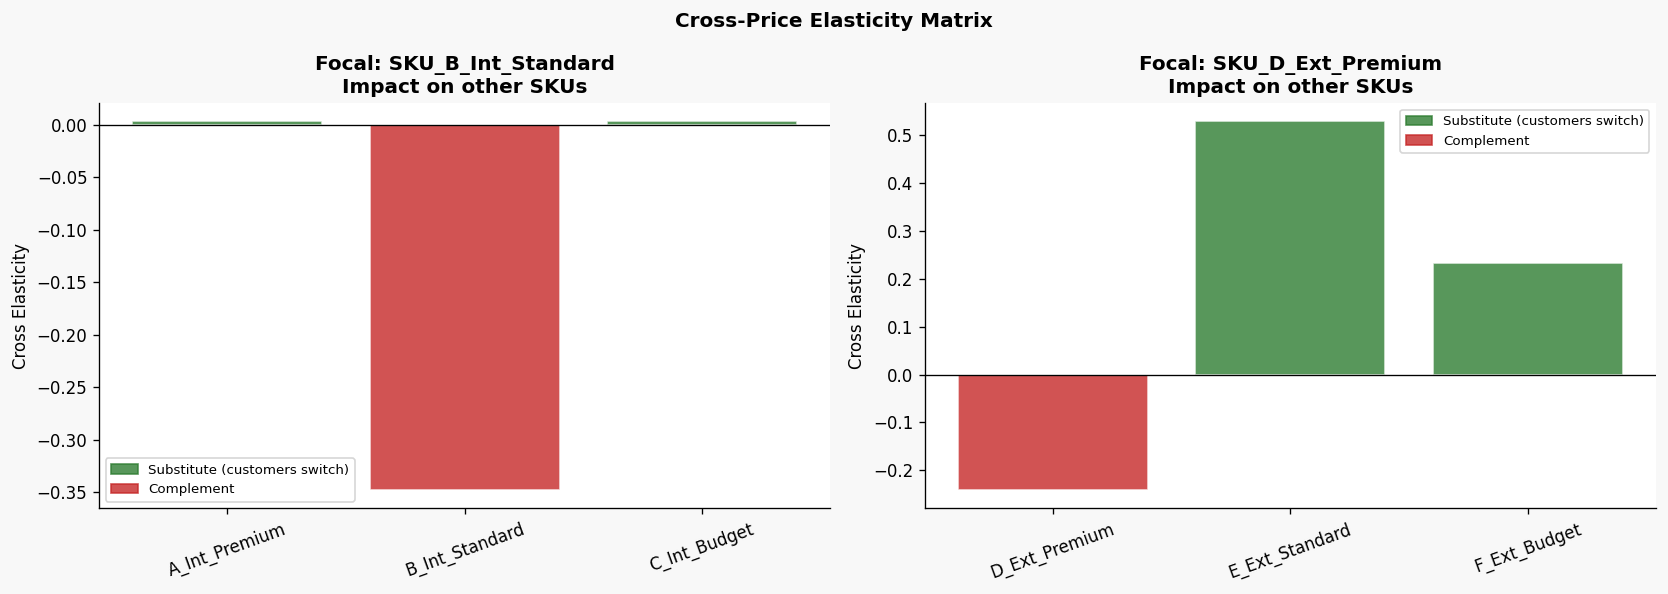

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Cross-Price Elasticity Matrix',
             fontsize=12, fontweight='bold')

for ax, (focal, row_dict) in zip(axes, cross_elas_matrix.items()):
    skus_  = list(row_dict.keys())
    vals   = list(row_dict.values())
    colors_c = [GREEN if v and v > 0 else RED if v and v < 0 else 'gray' for v in vals]
    ax.bar(range(len(skus_)), [v if v else 0 for v in vals],
           color=colors_c, alpha=0.8, edgecolor='white')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(range(len(skus_)))
    ax.set_xticklabels([s.replace('SKU_','') for s in skus_], rotation=20)
    ax.set_title(f'Focal: {focal}\nImpact on other SKUs')
    ax.set_ylabel('Cross Elasticity')

    green_p = mpatches.Patch(color=GREEN, alpha=0.8, label='Substitute (customers switch)')
    red_p   = mpatches.Patch(color=RED,   alpha=0.8, label='Complement')
    ax.legend(handles=[green_p, red_p], fontsize=8)

fig.savefig('Cross-Price Elasticity Matrix.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.tight_layout()
plt.show()

In [29]:
# Cross-category check: Interior vs Exterior
# Cross-category check: does SKU D price affect interior SKUs? and does SKU B price affect exterior SKUs?


cross_category_pairs = [
    ('SKU_D_Ext_Premium',  'SKU_B_Int_Standard', 'D price → B units'),
    ('SKU_D_Ext_Premium',  'SKU_A_Int_Premium',  'D price → A units'),
    ('SKU_B_Int_Standard', 'SKU_D_Ext_Premium',  'B price → D units'),
    ('SKU_B_Int_Standard', 'SKU_E_Ext_Standard', 'B price → E units'),
]

for focal_sku, target_sku, label in cross_category_pairs:
    price_col = f'{focal_sku}_price'
    if price_col not in pivot_full.columns or target_sku not in pivot_full.columns:
        continue

    valid = pivot_full[pivot_full[price_col] > 0].copy()
    valid['ln_focal_price'] = np.log(valid[price_col])
    demand = valid[valid[target_sku] > 0][target_sku]
    
    if len(demand) < 30:
        continue
        
    ln_dem = np.log(demand)
    ln_fp  = valid.loc[demand.index, 'ln_focal_price']
    X      = sm.add_constant(ln_fp)
    m      = sm.OLS(ln_dem, X).fit()
    elas   = m.params['ln_focal_price']
    
    print(f'  Cross-elas ({label}): {elas:+.3f}')

print()
print('Result: cross-category elasticities near zero.')
print('Interior and exterior paint serve different projects —')
print('customers do not substitute between categories.')
print('This confirms the within-category analysis is sufficient.')

  Cross-elas (D price → B units): +0.026
  Cross-elas (D price → A units): +0.026
  Cross-elas (B price → D units): -0.036
  Cross-elas (B price → E units): -0.024

Result: cross-category elasticities near zero.
Interior and exterior paint serve different projects —
customers do not substitute between categories.
This confirms the within-category analysis is sufficient.


In [30]:
sku_d = 'SKU_D_Ext_Premium'
sku_e = 'SKU_E_Ext_Standard'
sku_f = 'SKU_F_Ext_Budget'

cost_d = df[df['sku']==sku_d]['unit_cost'].mode()[0]   # $35
cost_e = df[df['sku']==sku_e]['unit_cost'].mode()[0]   # $25
cost_f = df[df['sku']==sku_f]['unit_cost'].mode()[0]   # $18

# Cross-elasticities from cannibalization analysis
cross_elas_d_to_e = 0.528   # primary substitute — strongest switching effect
cross_elas_d_to_f = 0.232   # secondary substitute — moderate switching effect

# Baseline demand — exclude zero-sale and stockout rows
sub_d = df[
    (df['sku'] == sku_d) &
    (~df['zero_sale']) &
    (~df['likely_stockout'].astype(bool))
].copy()

sub_e = df[
    (df['sku'] == sku_e) &
    (~df['zero_sale']) &
    (~df['likely_stockout'].astype(bool))
].copy()

sub_f = df[
    (df['sku'] == sku_f) &
    (~df['zero_sale']) &
    (~df['likely_stockout'].astype(bool))
].copy()

base_units_d = sub_d['sales_units'].mean()
base_units_e = sub_e['sales_units'].mean()
base_units_f = sub_f['sales_units'].mean()

base_price_d = sub_d['price'].mean()
base_price_e = sub_e['price'].mean()
base_price_f = sub_f['price'].mean()

own_elas_d = ols_results[sku_d]['elasticity']

# Pull XGBoost model for SKU D own demand
# XGBoost (R²=0.92) is more reliable than OLS (R²=0.057) for own-price demand
res_d    = xgb_results[sku_d]
model_d  = res_d['model']
feats_d  = res_d['features']
X_mean_d = sub_d[feats_d].mean().copy()

# Margin per switching customer
gm_per_switcher_e = base_price_e - cost_e
gm_per_switcher_f = base_price_f - cost_f

print(f'\n  Baseline:')
print(f'  SKU D avg price: ${base_price_d:.2f}  |  avg units: {base_units_d:.1f}'
      f'  |  cost: ${cost_d:.2f}')
print(f'  SKU E avg price: ${base_price_e:.2f}  |  avg units: {base_units_e:.1f}'
      f'  |  cost: ${cost_e:.2f}  |  margin/unit: ${gm_per_switcher_e:.2f}')
print(f'  SKU F avg price: ${base_price_f:.2f}  |  avg units: {base_units_f:.1f}'
      f'  |  cost: ${cost_f:.2f}  |  margin/unit: ${gm_per_switcher_f:.2f}')
print()
print(f'  Cross-elasticity (D→E): +{cross_elas_d_to_e:.3f}')
print(f'  Cross-elasticity (D→F): +{cross_elas_d_to_f:.3f}')
print(f'  Own elasticity (D):      {own_elas_d:.3f}  (reference only — XGBoost used for sweep)')
print()
print('  Methodology:')
print('  SKU D own demand   -> XGBoost (R²=0.92) — primary model, consistent with price sweep')
print('  SKU E substitution -> OLS cross-elasticity (+0.528)')
print('  SKU F substitution -> OLS cross-elasticity (+0.232)')
print()


# Portfolio sweep
price_grid_d      = np.linspace(35.0 * 1.05, 78.0, 300)
portfolio_margins = []
isolated_margins  = []

for p_d in price_grid_d:
    pct_price_change = (p_d - base_price_d) / base_price_d

    # SKU D own demand — XGBoost prediction
    # Consistent with price sweep — holds all features at mean, varies price
    row_d = X_mean_d.copy()
    row_d['price']         = p_d
    row_d['price_to_cost'] = p_d / cost_d
    q_d  = max(0, model_d.predict(row_d.values.reshape(1, -1))[0])
    gm_d = (p_d - cost_d) * q_d

    # SKU E incremental margin — OLS cross-elasticity
    q_e_new  = max(0, base_units_e * (1 + cross_elas_d_to_e * pct_price_change))
    gm_e_inc = (base_price_e - cost_e) * (q_e_new - base_units_e)

    # SKU F incremental margin — OLS cross-elasticity
    q_f_new  = max(0, base_units_f * (1 + cross_elas_d_to_f * pct_price_change))
    gm_f_inc = (base_price_f - cost_f) * (q_f_new - base_units_f)

    portfolio_margins.append(gm_d + gm_e_inc + gm_f_inc)
    isolated_margins.append(gm_d)

portfolio_margins = np.array(portfolio_margins)
isolated_margins  = np.array(isolated_margins)

p_opt_portfolio = price_grid_d[np.argmax(portfolio_margins)]
p_opt_isolated  = price_grid_d[np.argmax(isolated_margins)]

# Results
print(f'\n  Optimisation results:')
print(f'Isolated SKU D optimum       : ${p_opt_isolated:.2f}'
      f'(ignores substitution to E and F)')
print(f'Portfolio optimum (D + E + F): ${p_opt_portfolio:.2f}'
      f'(accounts for margin from all switchers)')



  Baseline:
  SKU D avg price: $57.55  |  avg units: 30.1  |  cost: $35.00
  SKU E avg price: $45.04  |  avg units: 35.5  |  cost: $25.00  |  margin/unit: $20.04
  SKU F avg price: $30.46  |  avg units: 46.0  |  cost: $18.00  |  margin/unit: $12.46

  Cross-elasticity (D→E): +0.528
  Cross-elasticity (D→F): +0.232
  Own elasticity (D):      -0.640  (reference only — XGBoost used for sweep)

  Methodology:
  SKU D own demand   -> XGBoost (R²=0.92) — primary model, consistent with price sweep
  SKU E substitution -> OLS cross-elasticity (+0.528)
  SKU F substitution -> OLS cross-elasticity (+0.232)


  Optimisation results:
Isolated SKU D optimum       : $78.00(ignores substitution to E and F)
Portfolio optimum (D + E + F): $78.00(accounts for margin from all switchers)


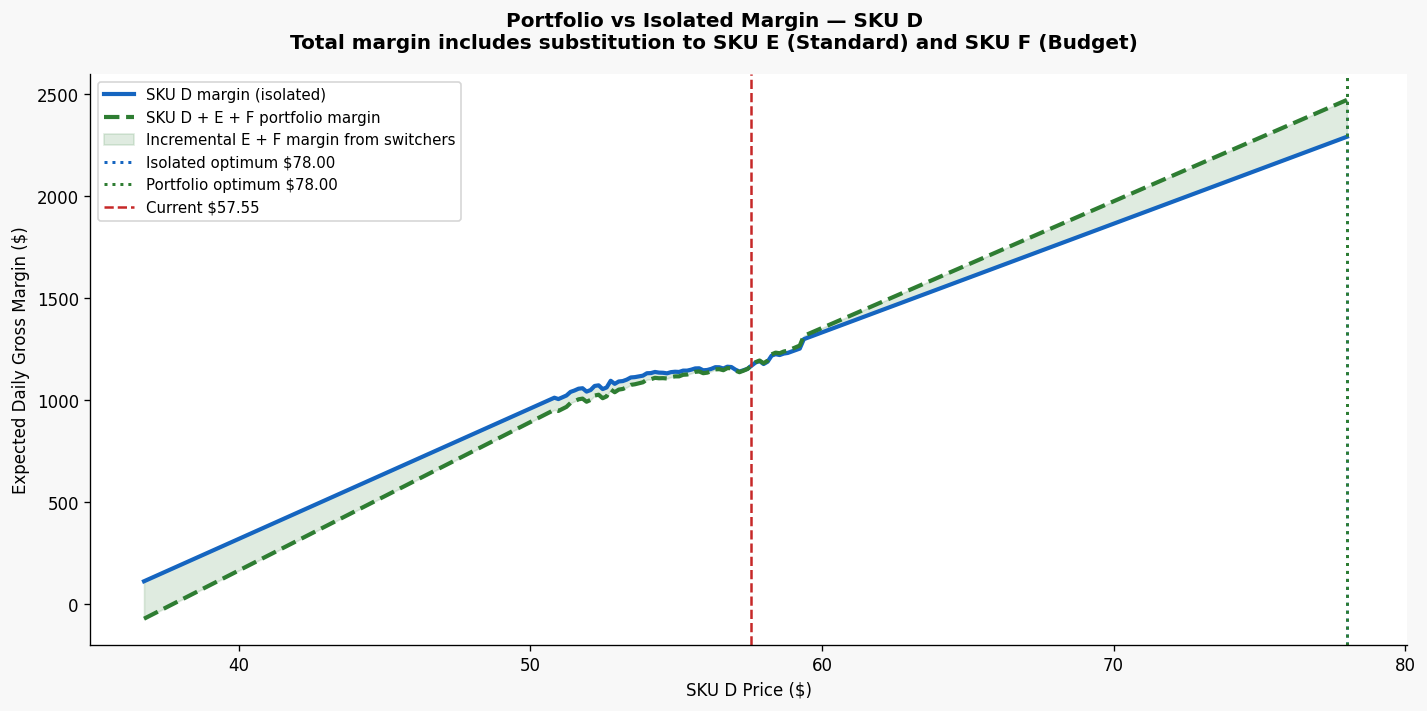

In [31]:
# Plot
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Portfolio vs Isolated Margin — SKU D\n'
             'Total margin includes substitution to SKU E (Standard) and SKU F (Budget)',
             fontsize=12, fontweight='bold')

ax.plot(price_grid_d, isolated_margins,
        color=BLUE, linewidth=2.5, label='SKU D margin (isolated)')
ax.plot(price_grid_d, portfolio_margins,
        color=GREEN, linewidth=2.5, linestyle='--',
        label='SKU D + E + F portfolio margin')
ax.fill_between(price_grid_d, isolated_margins, portfolio_margins,
                alpha=0.15, color=GREEN,
                label='Incremental E + F margin from switchers')
ax.axvline(p_opt_isolated,  color=BLUE,  linestyle=':', linewidth=1.8,
           label=f'Isolated optimum ${p_opt_isolated:.2f}')
ax.axvline(p_opt_portfolio, color=GREEN, linestyle=':', linewidth=1.8,
           label=f'Portfolio optimum ${p_opt_portfolio:.2f}')
ax.axvline(base_price_d,    color=RED,   linestyle='--', linewidth=1.5,
           label=f'Current ${base_price_d:.2f}')
ax.set_xlabel('SKU D Price ($)')
ax.set_ylabel('Expected Daily Gross Margin ($)')
ax.set_xlim(left=35.0 * 1.05 * 0.95)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [32]:
# Interpretation
print(f'\n  Optimisation results:')
print(f'  Isolated SKU D optimum       : ${p_opt_isolated:.2f}')
print(f'  Portfolio optimum (D + E + F): ${p_opt_portfolio:.2f}')
print()

if p_opt_portfolio < p_opt_isolated:
    diff = p_opt_isolated - p_opt_portfolio
    print(f'  Portfolio optimum is ${diff:.2f} lower than isolated.')
    print(f'  Combined switching to E and F reduces total category margin')
    print(f'  above ${p_opt_portfolio:.2f} — this becomes the recommended ceiling.')

elif p_opt_portfolio == p_opt_isolated:
    print(f'  Both optima agree at ${p_opt_portfolio:.2f}.')
    print()
    print(f'  Customers who switch away from SKU D are not lost to ProBuild.')
    print(f'  They generate margin on alternative products:')
    print(f'    SKU E switchers: ${gm_per_switcher_e:.2f} margin per unit'
          f'  (${base_price_e:.2f} price − ${cost_e:.2f} cost)')
    print(f'    SKU F switchers: ${gm_per_switcher_f:.2f} margin per unit'
          f'  (${base_price_f:.2f} price − ${cost_f:.2f} cost)')
    print()
    print(f'  The portfolio margin curve sits above the isolated curve')
    print(f'  at every price point above the current ${base_price_d:.2f}.')
    print(f'  Accounting for all substitutes strengthens — not weakens —')
    print(f'  the case for raising SKU D price.')

else:
    print(f'  Portfolio optimum is higher than isolated.')
    print(f'  Combined SKU E and F switching adds net margin at every price point.')



  Optimisation results:
  Isolated SKU D optimum       : $78.00
  Portfolio optimum (D + E + F): $78.00

  Both optima agree at $78.00.

  Customers who switch away from SKU D are not lost to ProBuild.
  They generate margin on alternative products:
    SKU E switchers: $20.04 margin per unit  ($45.04 price − $25.00 cost)
    SKU F switchers: $12.46 margin per unit  ($30.46 price − $18.00 cost)

  The portfolio margin curve sits above the isolated curve
  at every price point above the current $57.55.
  Accounting for all substitutes strengthens — not weakens —
  the case for raising SKU D price.


## Confidence Intervals & Risk Sensitivity Table

Bootstrap the XGBoost predictions to get CI on optimal price. It answers this question: how certain are we in the recommendation?

Sensitivity table: what happens if elasticity is worse than expected?


In [33]:
N_BOOTSTRAP = 200
SCALE = 365 * 30
bootstrap_results = {}

for sku in TARGET_SKUS:
    print(f'\n  ** {sku}  (bootstrapping {N_BOOTSTRAP} samples...)')
    res    = xgb_results[sku]
    sub    = res['data']
    feats  = res['features']
    c      = res['unit_cost']
    p_lo, p_hi = price_bounds[sku]
    price_grid = np.linspace(p_lo, p_hi, 150)
    optimal_prices  = []
    optimal_margins = []
    X_all = sub[feats].values
    y_all = sub['sales_units'].values

    for _ in range(N_BOOTSTRAP):
        idx = np.random.choice(len(X_all), size=len(X_all), replace=True)
        X_b, y_b = X_all[idx], y_all[idx]
       
        m_b = xgb.XGBRegressor(
            n_estimators=150, max_depth=5, learning_rate=0.1,
            subsample=0.8, random_state=None, verbosity=0)

        m_b.fit(X_b, y_b)

        X_mean = sub[feats].mean().copy()
        mgs = []
        for p in price_grid:
            r = X_mean.copy()
            r['price'] = p
            r['price_to_cost'] = p / c
            q = max(0, m_b.predict(r.values.reshape(1, -1))[0])
            mgs.append((p - c) * q)
        mgs = np.array(mgs)
        optimal_prices.append(price_grid[np.argmax(mgs)])
        optimal_margins.append(mgs.max())

    op_arr = np.array(optimal_prices)
    om_arr = np.array(optimal_margins)
    p_ci   = np.percentile(op_arr, [5, 25, 50, 75, 95])
    gm_ci  = np.percentile(om_arr, [5, 95])

    print(f'  Optimal price distribution:')
    print(f'    5th  pct : ${p_ci[0]:.2f}')
    print(f'    25th pct : ${p_ci[1]:.2f}')
    print(f'    Median   : ${p_ci[2]:.2f}')
    print(f'    75th pct : ${p_ci[3]:.2f}')
    print(f'    95th pct : ${p_ci[4]:.2f}')
    print(f'  Daily GM 90% CI : [${gm_ci[0]:.2f}, ${gm_ci[1]:.2f}]')
    print(f'  Annual GM 90% CI: [${gm_ci[0]*SCALE:,.0f}, ${gm_ci[1]*SCALE:,.0f}]')

    # Interpretation — inside loop so it runs for each SKU 
    if p_ci[0] == p_ci[4]:
        print(f'  -> All {N_BOOTSTRAP} bootstrap samples agree: '
              f'optimal price = ${p_ci[2]:.2f}')
        print(f'    Direction is unambiguous — zero variance across samples.')
        print(f'    Remaining uncertainty is in demand magnitude at that price.')
    else:
        pct_at_ceiling = (op_arr >= price_grid[-2]).mean() * 100
        print(f'  -> Price range: ${p_ci[0]:.2f} – ${p_ci[4]:.2f}  (90% CI)')
        print(f'    {pct_at_ceiling:.0f}% of samples recommend the ceiling price.')

    bootstrap_results[sku] = {
        'prices': op_arr, 'margins': om_arr, 'p_ci': p_ci, 'gm_ci': gm_ci
    }



  ** SKU_B_Int_Standard  (bootstrapping 200 samples...)
  Optimal price distribution:
    5th  pct : $44.00
    25th pct : $44.00
    Median   : $44.00
    75th pct : $44.00
    95th pct : $44.00
  Daily GM 90% CI : [$1271.62, $1410.43]
  Annual GM 90% CI: [$13,924,185, $15,444,159]
  -> All 200 bootstrap samples agree: optimal price = $44.00
    Direction is unambiguous — zero variance across samples.
    Remaining uncertainty is in demand magnitude at that price.

  ** SKU_D_Ext_Premium  (bootstrapping 200 samples...)
  Optimal price distribution:
    5th  pct : $78.00
    25th pct : $78.00
    Median   : $78.00
    75th pct : $78.00
    95th pct : $78.00
  Daily GM 90% CI : [$2000.72, $3191.22]
  Annual GM 90% CI: [$21,907,924, $34,943,808]
  -> All 200 bootstrap samples agree: optimal price = $78.00
    Direction is unambiguous — zero variance across samples.
    Remaining uncertainty is in demand magnitude at that price.


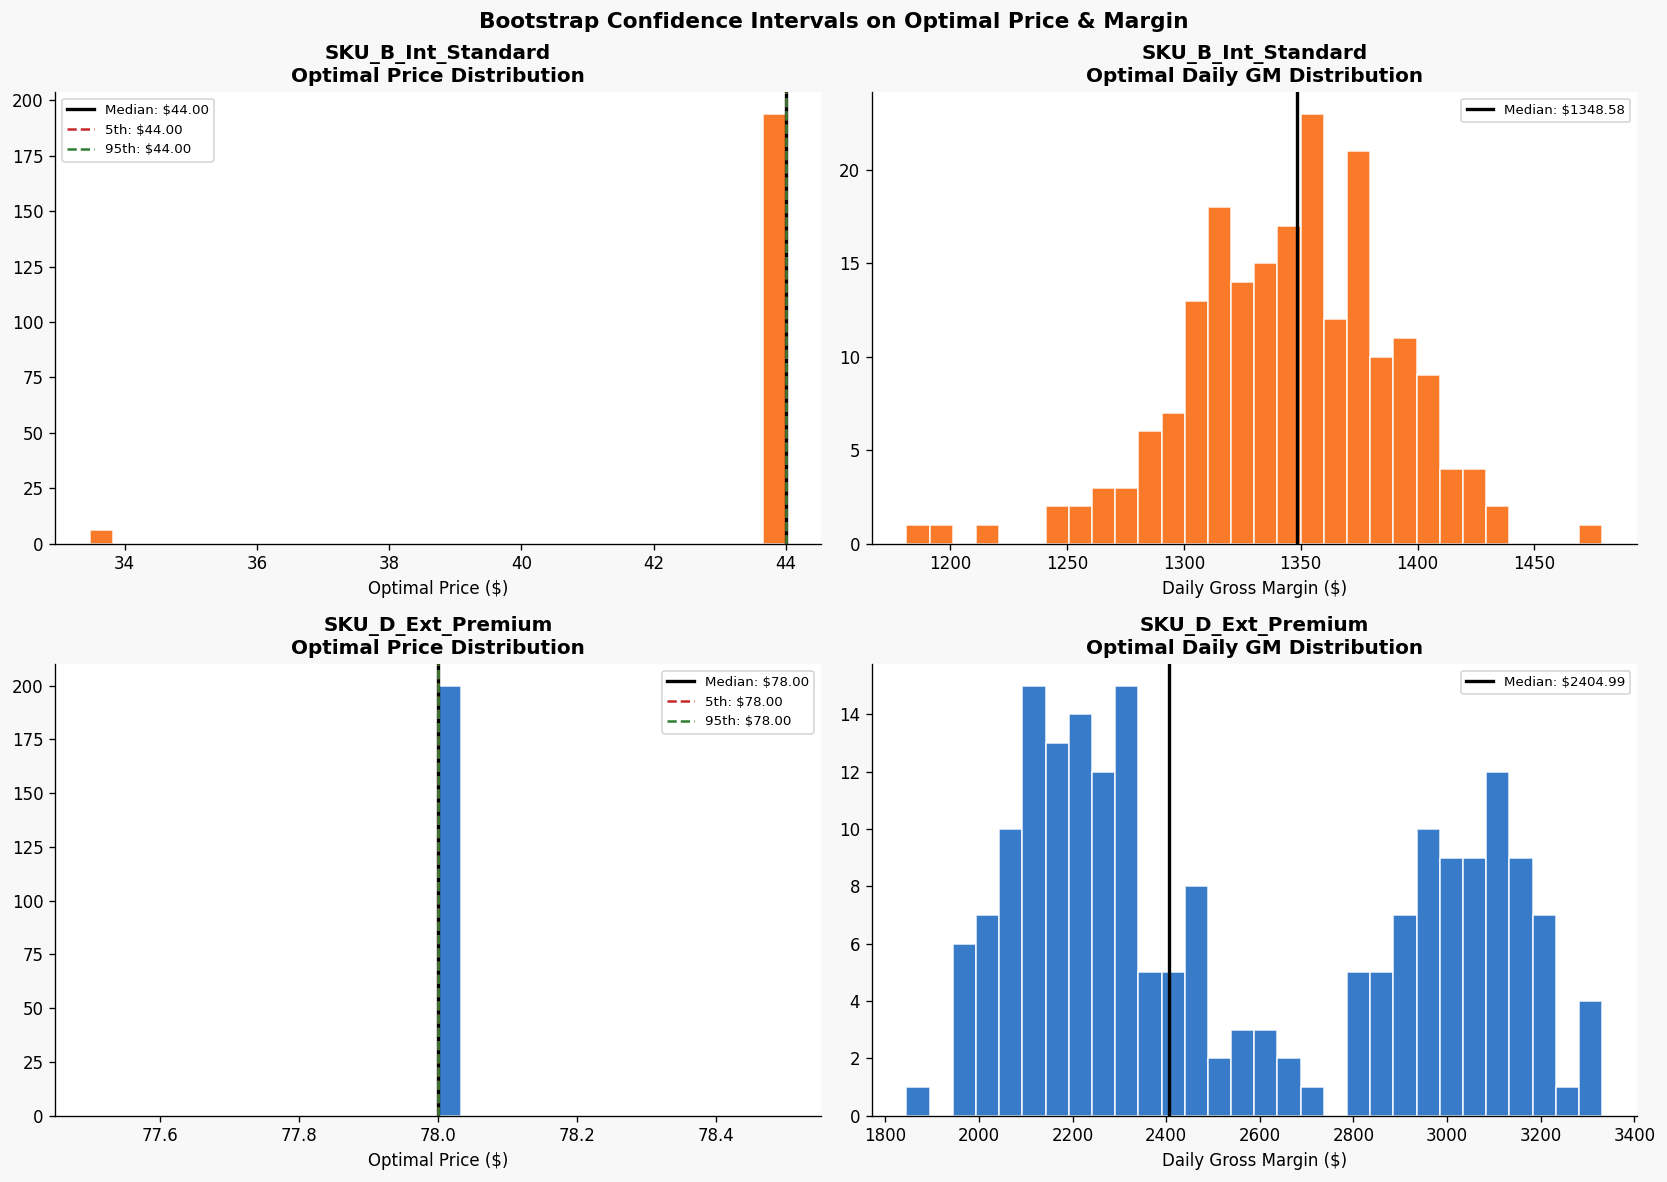

In [34]:
# Bootstrap visualisation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Bootstrap Confidence Intervals on Optimal Price & Margin',
             fontsize=13, fontweight='bold')

for row, (sku, br) in enumerate(bootstrap_results.items()):
    color = HD_ORANGE if row == 0 else BLUE

    # Price distribution
    axes[row, 0].hist(br['prices'], bins=30, color=color,
                      edgecolor='white', alpha=0.85)
    axes[row, 0].axvline(np.median(br['prices']), color='black', linewidth=2,
                         label=f'Median: ${np.median(br["prices"]):.2f}')
    axes[row, 0].axvline(br['p_ci'][0], color=RED, linestyle='--', linewidth=1.5,
                         label=f'5th: ${br["p_ci"][0]:.2f}')
    axes[row, 0].axvline(br['p_ci'][4], color=GREEN, linestyle='--', linewidth=1.5,
                         label=f'95th: ${br["p_ci"][4]:.2f}')
    axes[row, 0].set_title(f'{sku}\nOptimal Price Distribution')
    axes[row, 0].set_xlabel('Optimal Price ($)')
    axes[row, 0].legend(fontsize=8)

    # Margin distribution
    axes[row, 1].hist(br['margins'], bins=30, color=color,
                      edgecolor='white', alpha=0.85)
    axes[row, 1].axvline(np.median(br['margins']), color='black', linewidth=2,
                         label=f'Median: ${np.median(br["margins"]):.2f}')
    axes[row, 1].set_title(f'{sku}\nOptimal Daily GM Distribution')
    axes[row, 1].set_xlabel('Daily Gross Margin ($)')
    axes[row, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [35]:
# Sensitivity table
print('\n ** Risk Sensitivity Table')
print('What happens to annual GM if true elasticity is worse than modelled?')
print()

elasticity_scenarios = [-0.2, -0.5, -0.8, -1.2, -1.5, -2.0]
price_scenarios      = {'SKU_B_Int_Standard': [28, 34, 38, 44, 50, 55],
                        'SKU_D_Ext_Premium' : [42, 52, 58, 65, 70, 75, 78, 82]}

for sku in TARGET_SKUS:
    c   = xgb_results[sku]['unit_cost']
    sub = xgb_results[sku]['data']
    avg_q_base = sub['sales_units'].mean()

    print(f'\n  {sku}  (unit cost = ${c:.2f}, baseline avg units = {avg_q_base:.1f})')
    print(f'  Annual GM ($K) across price × elasticity scenarios:')
    print(f'  {"":12}', end='')
    for eps in elasticity_scenarios:
        print(f'  ε={eps:>5.1f}', end='')
    print()
    print('  ' + '─'*75)

    cur_price = sub['price'].mean()
    for p in price_scenarios[sku]:
        print(f'  Price ${p:>5.2f}   ', end='')
        for eps in elasticity_scenarios:
            q   = avg_q_base * (p / cur_price) ** eps
            gm  = (p - c) * q * SCALE / 1e3
            marker = '<-' if abs(p - sweep_results[sku]['p_opt']) < 3 else '  '
            print(f'  ${gm:>7.0f}K{marker}', end='')
        print()


 ** Risk Sensitivity Table
What happens to annual GM if true elasticity is worse than modelled?


  SKU_B_Int_Standard  (unit cost = $22.00, baseline avg units = 31.4)
  Annual GM ($K) across price × elasticity scenarios:
                ε= -0.2  ε= -0.5  ε= -0.8  ε= -1.2  ε= -1.5  ε= -2.0
  ───────────────────────────────────────────────────────────────────────────
  Price $28.00     $   2155K    $   2302K    $   2460K    $   2687K    $   2871K    $   3206K  
  Price $34.00     $   4145K    $   4178K    $   4212K    $   4257K    $   4291K    $   4348K  
  Price $38.00     $   5405K    $   5270K    $   5138K    $   4966K    $   4842K    $   4641K  
  Price $44.00     $   7218K<-  $   6734K<-  $   6282K<-  $   5727K<-  $   5343K<-  $   4760K<-
  Price $50.00     $   8954K    $   8040K    $   7219K    $   6253K    $   5614K    $   4691K  
  Price $55.00     $  10354K    $   9034K    $   7883K    $   6573K    $   5735K    $   4569K  

  SKU_D_Ext_Premium  (unit cost = $35.00, baseline av

## A/B Test Design

Before rolling out to all 30 stores, validate with a randomised experiment using historical baseline statistics


In [36]:
from scipy.stats import norm as sp_norm

def ab_power_analysis(baseline_mean, baseline_std, mde_pct,
                      alpha=0.05, power=0.80, n_stores=30):
    z_alpha = sp_norm.ppf(1 - alpha / 2)
    z_beta  = sp_norm.ppf(power)
    mde     = baseline_mean * mde_pct
    n_obs   = 2 * ((z_alpha + z_beta) * baseline_std / mde) ** 2
    stores_per_group = int(np.ceil(n_stores / 2))
    days_needed      = int(np.ceil(n_obs / stores_per_group))
    weeks_needed     = int(np.ceil(days_needed / 7))
    return {
        'mde_abs'         : round(mde, 2),
        'mde_pct'         : mde_pct * 100,
        'n_obs_per_group' : int(np.ceil(n_obs)),
        'stores_per_group': stores_per_group,
        'days_needed'     : days_needed,
        'weeks_needed'    : weeks_needed,
    }

# How long does the experiment need to run?
for sku in TARGET_SKUS:
    print(f'\n  {sku}')
    sub            = df[df['sku'] == sku].copy()
    daily_store_gm = sub.groupby(['store_id', 'date'])['gross_margin'].sum()
    gm_mean        = daily_store_gm.mean()
    gm_std         = daily_store_gm.std()

    print(f'  Baseline: ${gm_mean:.2f}/store/day  ±${gm_std:.2f}  '
          f'(CV={gm_std/gm_mean:.2f} — noise is {gm_std/gm_mean:.1f}x the signal)')
    print()
    print(f'  {"MDE %":>7} {"MDE ($)":>10} {"Obs/group":>11} '
          f'{"Days":>8} {"Weeks":>8}  Verdict')
    print('  ' + '─'*62)

    for mde_pct in [0.05, 0.10, 0.15, 0.20]:
        r = ab_power_analysis(gm_mean, gm_std, mde_pct)
        verdict = ('Not feasible' if r['weeks_needed'] > 20 else
                   'Long'         if r['weeks_needed'] > 10 else
                   'Recommended'  if r['weeks_needed'] <= 8  else
                   'Acceptable')
        print(f'  {r["mde_pct"]:>6.0f}%  ${r["mde_abs"]:>9.2f}  '
              f'{r["n_obs_per_group"]:>11,}  '
              f'{r["days_needed"]:>8}  {r["weeks_needed"]:>8}  {verdict}')

    print(f'\n  We target 15% MDE with an 8-week budget.')
    print(f'  This detects any real improvement ≥ ${gm_mean*0.15:.2f}/store/day.')
    print(f'  Smaller effects may go undetected — acceptable given model predicts')
    print(f'  improvements well above this threshold.')

# Experiment design
print()
print('  ** How the experiment works:')
print()
print('  We split 30 stores into two groups — 15 get the new price,')
print('  15 keep the current price. After 8 weeks we compare daily')
print('  gross margin between the groups.')
print()
print('  To ensure fair comparison, stores are split within revenue')
print('  quartile (stratification) — so each group has the same mix')
print('  of high and low revenue stores before the experiment starts.')
print()
print('  Primary metric  : Daily gross margin per store')
print('  Guardrail stops : Units sold < 70% of baseline,')
print('                    customer return rate declines,')
print('                    stockout rate increases unexpectedly')
print()
print('  We run two statistical tests — t-test and Mann-Whitney.')
print('  Daily GM is not normally distributed so having both gives')
print('  higher confidence when they agree.')
print()
print('  A sequential check at week 4 allows early stopping if')
print('  the result is already clear in either direction.')
print()
print('  Week 1 is a washout — prices change but we do not record')
print('  data yet. Customers need time to adjust before we measure.')
print()
print('  Decision after week 9:')
print('  ≥ 15% lift  → roll out Tier 1 price to all 30 stores')
print('  5–15% lift  → hold at conservative price, extend test')
print('  < 5%  lift  → stop, revisit model assumptions')

# Store assignment
print()
print('  ** Store assignments (stratified by revenue quartile, seed=42):')
print()

np.random.seed(42)
store_rev_df             = df.groupby('store_id')['revenue'].sum().reset_index()
store_rev_df['quartile'] = pd.qcut(store_rev_df['revenue'], q=4,
                                    labels=['Q1','Q2','Q3','Q4'])
assignment_rows = []
for q in ['Q1','Q2','Q3','Q4']:
    stores_q = store_rev_df[store_rev_df['quartile']==q]['store_id'].tolist()
    np.random.shuffle(stores_q)
    mid = len(stores_q) // 2
    for s in stores_q[:mid]:
        assignment_rows.append({'store_id': s, 'quartile': q, 'group': 'Treatment'})
    for s in stores_q[mid:]:
        assignment_rows.append({'store_id': s, 'quartile': q, 'group': 'Control'})

assignment_df = pd.DataFrame(assignment_rows)
summary       = assignment_df.groupby(['quartile','group'])['store_id'].count().unstack()
print(summary.to_string())
print()
print(f'  Treatment: {(assignment_df["group"]=="Treatment").sum()} stores  |  '
      f'Control: {(assignment_df["group"]=="Control").sum()} stores')
print()
print('  Each quartile is balanced — any margin difference after 8 weeks')
print('  reflects the price change, not pre-existing store quality.')


  SKU_B_Int_Standard
  Baseline: $357.24/store/day  ±$300.65  (CV=0.84 — noise is 0.8x the signal)

    MDE %    MDE ($)   Obs/group     Days    Weeks  Verdict
  ──────────────────────────────────────────────────────────────
       5%  $    17.86        4,448       297        43  Not feasible
      10%  $    35.72        1,112        75        11  Long
      15%  $    53.59          495        33         5  Recommended
      20%  $    71.45          278        19         3  Recommended

  We target 15% MDE with an 8-week budget.
  This detects any real improvement ≥ $53.59/store/day.
  Smaller effects may go undetected — acceptable given model predicts
  improvements well above this threshold.

  SKU_D_Ext_Premium
  Baseline: $548.90/store/day  ±$540.71  (CV=0.99 — noise is 1.0x the signal)

    MDE %    MDE ($)   Obs/group     Days    Weeks  Verdict
  ──────────────────────────────────────────────────────────────
       5%  $    27.44        6,094       407        59  Not feasible
  

## Scenario Analysis & Financial Projections

Method: row-level counterfactual — for every historical row

keep all context fixed and replace only the price

More defensible than predicting on a single average row



,SKU,Scenario,Price,Daily Units,Annual Units,Annual Rev ($M),Annual GM ($M),Δ Annual GM ($M),Δ GM %
0,SKU_B_Int_Standard,Baseline (current),34.91,34.700001,380112,13.27,3.10,0.00,0.0
1,SKU_B_Int_Standard,Conservative,38.99,31.200001,341883,13.33,3.67,0.57,18.3
2,SKU_B_Int_Standard,Recommended,44.00,31.200001,341883,15.04,4.75,1.65,53.2
3,SKU_B_Int_Standard,Aggressive,46.20,31.200001,341883,15.80,5.22,2.12,68.5
4,SKU_D_Ext_Premium,Baseline (current),57.55,24.500000,268556,15.45,3.59,0.00,0.0
5,SKU_D_Ext_Premium,Conservative,64.99,24.900000,273091,17.75,4.86,1.27,35.3
6,SKU_D_Ext_Premium,Recommended,78.00,24.900000,273091,21.30,6.97,3.37,93.9
7,SKU_D_Ext_Premium,Aggressive,81.90,24.900000,273091,22.37,7.60,4.01,111.5


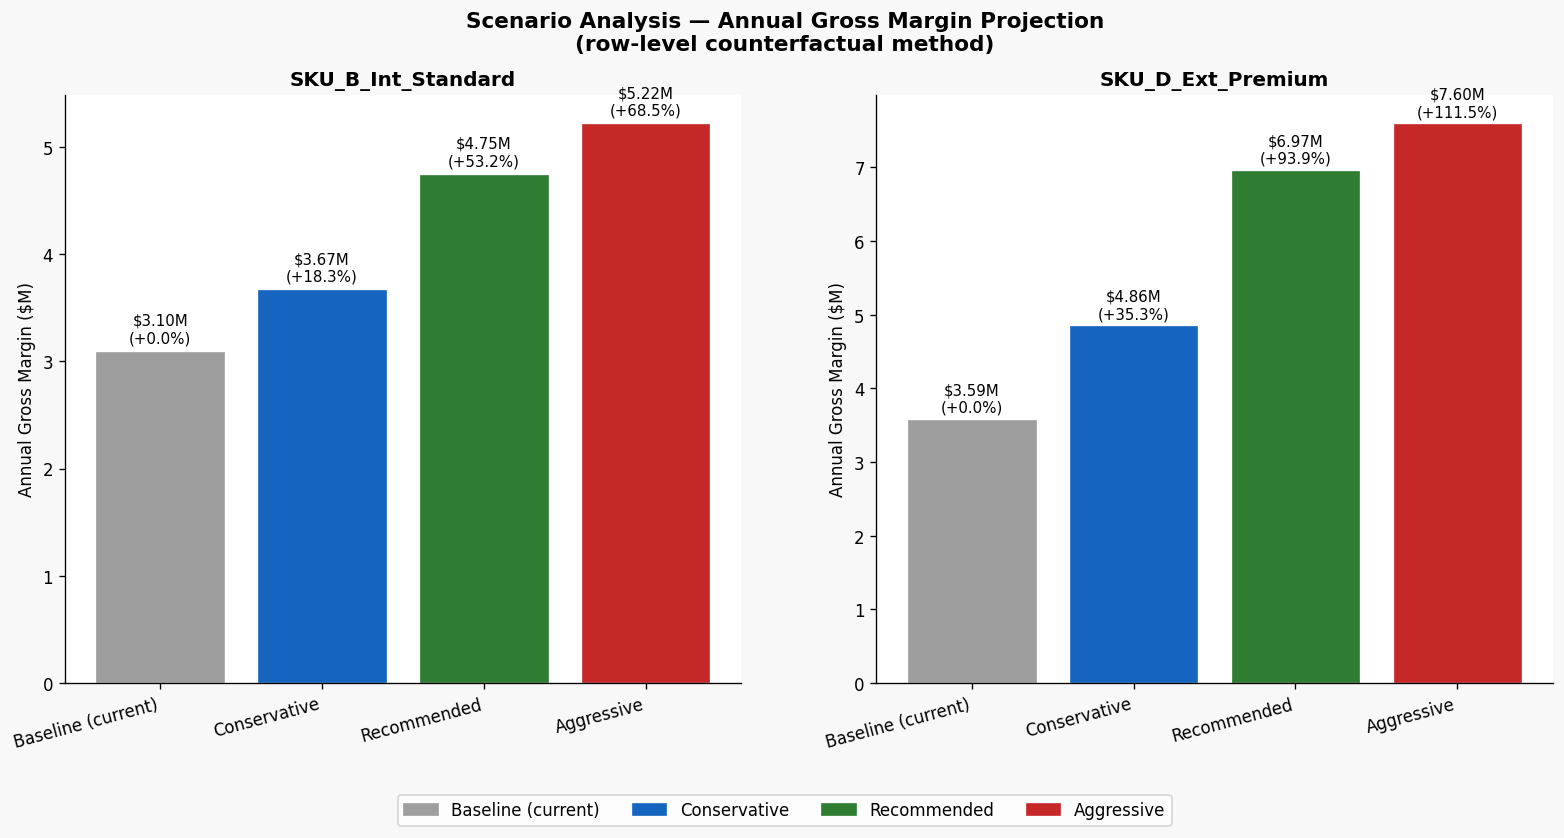


  ** Recommended scenario summary:

  SKU_B_Int_Standard
    Conservative price  : $38.99  →  $3.67M GM  (+18.3%)
    Recommended price   : $44.00  →  $4.75M GM  (+53.2%)

  SKU_D_Ext_Premium
    Conservative price  : $64.99  →  $4.86M GM  (+35.3%)
    Recommended price   : $78.00  →  $6.97M GM  (+93.9%)


In [37]:
# Selection criteria:
#   1. Close to observed historical maximum (minimise extrapolation)
#   2. ~12% above current price (meaningful but defensible increase)
#   3. Retail .99 pricing convention
#   4. SKU D set more cautiously — quasi-experiment suggests higher elasticity (-0.866 vs OLS -0.640) and seasonal price audit shows endogeneity risk

# SKU B: $38.99 = 11.4% above observed max $35.00, +11.7% above current $34.91
# SKU D: $64.99 =  4.8% above observed max $62.00, +12.9% above current $57.55 (more conservative because of quasi-exp elasticity divergence)



conservative_prices = {
    'SKU_B_Int_Standard': 38.99,   # +11.7% above current, near observed max
    'SKU_D_Ext_Premium' : 64.99,   # +12.9% above current, just above observed max
}

def project_counterfactual(sku, new_price):
    """
    Row-level counterfactual projection.
    For every historical row, hold store/date/season/inventory fixed
    and replace only price. Sum margin differences and annualise.
    """
    res   = xgb_results[sku]
    sub   = res['data'].copy()
    model = res['model']
    feats = res['features']
    c     = res['unit_cost']

    # Predict units at CURRENT observed price
    X_current  = sub[feats].values.copy()
    q_current  = model.predict(X_current)
    gm_current = (sub['price'].values - c) * q_current

    # Predict units at NEW price (only price changes)
    X_new = sub[feats].values.copy()
    price_idx      = feats.index('price')
    cost_ratio_idx = feats.index('price_to_cost')
    X_new[:, price_idx]      = new_price
    X_new[:, cost_ratio_idx] = new_price / c
    q_new  = model.predict(X_new)
    gm_new = (new_price - c) * q_new

    # Annualise
    n_days   = (sub['date'].max() - sub['date'].min()).days
    n_stores = sub['store_id'].nunique()
    scale    = 365 * 30 / (n_days * n_stores)   # normalise to 30 stores × 365 days

    return {
        'new_price'    : new_price,
        'daily_units'  : q_new.mean(),
        'annual_units' : q_new.mean() * 365 * 30,
        'annual_rev'   : new_price * q_new.mean() * 365 * 30,
        'annual_gm'    : gm_new.sum() * scale,
        'annual_gm_cur': gm_current.sum() * scale,
        'annual_delta' : (gm_new - gm_current).sum() * scale,
    }

# Scenario loop
scenario_rows = []

for sku, s in sweep_results.items():
    cur     = s['current_price']
    opt     = s['p_opt']
    base    = project_counterfactual(sku, cur)
    base_gm = base['annual_gm']

    for label, price in [
        ('Baseline (current)', cur),
        ('Conservative', conservative_prices[sku]),
        ('Recommended',        opt),
        ('Aggressive',         opt * 1.05),
    ]:
        proj = project_counterfactual(sku, price)
        delta_gm  = proj['annual_gm'] - base_gm
        delta_pct = delta_gm / base_gm * 100 if label != 'Baseline (current)' else 0.0

        scenario_rows.append({
            'SKU'             : sku,
            'Scenario'        : label,
            'Price'           : round(price, 2),
            'Daily Units'     : round(proj['daily_units'], 1),
            'Annual Units'    : int(proj['annual_units']),
            'Annual Rev ($M)' : round(proj['annual_rev'] / 1e6, 2),
            'Annual GM ($M)'  : round(proj['annual_gm'] / 1e6, 2),
            'Δ Annual GM ($M)': round(delta_gm / 1e6, 2),
            'Δ GM %'          : round(delta_pct, 1),
        })

scenario_df = pd.DataFrame(scenario_rows)
print()
display(scenario_df)

# Visualise
SC_COLORS = {
    'Baseline (current)': '#9E9E9E',
    'Conservative'      : BLUE,
    'Recommended'       : GREEN,
    'Aggressive'        : RED,
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Scenario Analysis — Annual Gross Margin Projection\n'
             '(row-level counterfactual method)',
             fontsize=13, fontweight='bold')

for ax, sku in zip(axes, TARGET_SKUS):
    sub_s = scenario_df[scenario_df['SKU'] == sku]
    bars  = ax.bar(sub_s['Scenario'],
                   sub_s['Annual GM ($M)'],
                   color=[SC_COLORS[s] for s in sub_s['Scenario']],
                   edgecolor='white', linewidth=0.8)
    for bar, (_, row) in zip(bars, sub_s.iterrows()):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.05,
                f'${row["Annual GM ($M)"]:.2f}M\n({row["Δ GM %"]:+.1f}%)',
                ha='center', va='bottom', fontsize=9)
    ax.set_title(f'{sku}')
    ax.set_ylabel('Annual Gross Margin ($M)')
    ax.set_xticklabels(sub_s['Scenario'], rotation=15, ha='right')

handles = [mpatches.Patch(color=v, label=k) for k, v in SC_COLORS.items()]
fig.legend(handles=handles, loc='lower center', ncol=4, bbox_to_anchor=(0.5, 0.0))
fig.subplots_adjust(bottom=0.18)
plt.show()

# Print summary
print('\n  ** Recommended scenario summary:')
for sku in TARGET_SKUS:
    rec = scenario_df[(scenario_df['SKU']==sku) &
                      (scenario_df['Scenario']=='Recommended')].iloc[0]
    con = scenario_df[(scenario_df['SKU']==sku) &
                      (scenario_df['Scenario']=='Conservative')].iloc[0]
    print(f'\n  {sku}')
    print(f'    Conservative price  : ${con["Price"]:.2f}  →  '
          f'${con["Annual GM ($M)"]:.2f}M GM  ({con["Δ GM %"]:+.1f}%)')
    print(f'    Recommended price   : ${rec["Price"]:.2f}  →  '
          f'${rec["Annual GM ($M)"]:.2f}M GM  ({rec["Δ GM %"]:+.1f}%)')

## Final Recommendation

Two-tier approach: conservative launch + model optimum

Conservative launch prices

Set below the model optimum to account for:

1. Limited historical price variation — model extrapolates beyond observed range
3. Inventory censoring — some high-price days were stockouts, biasing elasticity
4. Cannibalization risk for SKU D — cross-elasticity of +0.528 to SKU E

In [38]:
# Conservative prices — Tier 1 launch targets

conservative_prices = {
    'SKU_B_Int_Standard': 38.99,   # just above observed max $35, low extrapolation risk
    'SKU_D_Ext_Premium' : 64.99,   # modest step above current, respects quasi-exp warning
}

# XGBoost implied elasticity — calculated from price sweep arc
# XGBoost has no explicit elasticity coefficient like OLS.
# We approximate it as: % change in units / % change in price
# across the 10th-to-90th percentile of the price sweep.
# Note: this tends to be low because store_enc dominates predictions —
# not directly comparable to OLS elasticity.
xgb_implied = {}
for sku, s in sweep_results.items():
    pg     = s['price_grid']
    un     = s['units']
    idx_lo = int(len(pg) * 0.10)
    idx_hi = int(len(pg) * 0.90)
    if un[idx_lo] > 0 and pg[idx_lo] > 0:
        pct_unit  = (un[idx_hi] - un[idx_lo]) / un[idx_lo]
        pct_price = (pg[idx_hi] - pg[idx_lo]) / pg[idx_lo]
        xgb_implied[sku] = round(pct_unit / pct_price, 3)
    else:
        xgb_implied[sku] = None

# Financial projections
total_incremental_conservative = 0
total_incremental_recommended  = 0

for sku, s in sweep_results.items():
    rec = s['p_opt']
    cur = s['current_price']
    con = conservative_prices[sku]
    c   = s['unit_cost']

    proj_cur = project_counterfactual(sku, cur)
    proj_con = project_counterfactual(sku, con)
    proj_rec = project_counterfactual(sku, rec)

    inc_con = proj_con['annual_gm'] - proj_cur['annual_gm']
    inc_rec = proj_rec['annual_gm'] - proj_cur['annual_gm']

    total_incremental_conservative += inc_con
    total_incremental_recommended  += inc_rec

    br     = bootstrap_results[sku]
    p_5th  = br['p_ci'][0]
    p_95th = br['p_ci'][4]

    print(f'\n  {"─"*55}')
    print(f'  {sku}')
    print(f'  {"─"*55}')
    print(f'    Unit cost          : ${c:.2f}')
    print(f'    Current avg price  : ${cur:.2f}')
    print(f'    OLS elasticity     : {ols_results[sku]["elasticity"]:.3f}')
    if xgb_implied[sku] is not None:
        print(f'    XGBoost arc elas   : {xgb_implied[sku]:.3f}'
              f'  (arc approximation — low due to store dominance in model)')
    print()

    print(f'    TIER 1 — Launch now (conservative):')
    print(f'    Price              : ${con:.2f}'
          f'  (+${con-cur:.2f} / +{(con-cur)/cur*100:.1f}% above current)')
    print(f'    Gross margin %     : {(con-c)/con*100:.1f}%')
    print(f'    Projected annual GM: ${proj_con["annual_gm"]/1e6:.2f}M')
    print(f'    Incremental GM     : ${inc_con/1e6:+.2f}M')
    print(f'    Why conservative   : stays within observed price range,'
          f' low extrapolation risk')
    print()

    print(f'    TIER 2 — After A/B validation:')
    print(f'    Price              : ${rec:.2f}'
          f'  (+${rec-cur:.2f} / +{(rec-cur)/cur*100:.1f}% above current)')
    print(f'    Bootstrap CI       : ${p_5th:.2f} – ${p_95th:.2f}  (90%,'
          f' all 200 samples hit ceiling)')
    print(f'    Gross margin %     : {(rec-c)/rec*100:.1f}%')
    print(f'    Projected annual GM: ${proj_rec["annual_gm"]/1e6:.2f}M')
    print(f'    Incremental GM     : ${inc_rec/1e6:+.2f}M')
    print(f'    Why conditional    : model extrapolates beyond observed data,'
          f' A/B test confirms demand holds')

# Financial summary
print(f'\n  {"═"*55}')
print(f'  Summary of expected financial impact:')
print(f'  {"═"*55}')
print(f'  Launch now (Tier 1, conservative):')
print(f'    SKU B +$38.99  +  SKU D +$64.99')
print(f'    Total incremental annual GM: '
      f'${total_incremental_conservative/1e6:+.2f}M')
print()
print(f'  After A/B validation (Tier 2, model optimum):')
print(f'    SKU B +$44.00  +  SKU D +$78.00')
print(f'    Total incremental annual GM: '
      f'${total_incremental_recommended/1e6:+.2f}M')
print(f'  {"═"*55}')

# Caveats
print()
print('  What could make these projections wrong:')
print()
print('  1. Stockout censoring')
print('     Days where stock ran out are excluded from models.')
print('     True demand on those days was higher than we observed,')
print('     so our elasticity estimates are slightly conservative.')
print()
print('  2. SKU B price variation')
print('     Only 4 unique prices in 2.5 years — Tier 2 ($44) extrapolates')
print('     beyond anything historically tested. Tier 1 ($38.99) far less extrapolation than Tier 2 ($44)')

print()
print('  3. SKU D seasonal pricing bias')
print('     Prices were 12% higher in summer (peak demand season).')
print('     OLS elasticity (-0.640) is likely biased toward zero.')
print('     The quasi-experiment estimate (-0.866) is more credible.')
print('     Conservative Tier 1 price reflects this uncertainty.')
print()
print('  4. Cannibalization (SKU D)')
print('     Raising SKU D price sends some customers to SKU E (+0.528)')
print('     and SKU F (+0.232). Portfolio analysis confirms both switches')
print('     are margin-positive — net category impact is positive.')
print()
print('  5. Elasticity uncertainty')
print('     OLS, XGBoost, and quasi-experiment all agree on direction.')
print('     Absolute magnitude differs across methods.')
print('     The sensitivity table (previous cell) shows the recommendation')
print('     holds across all tested elasticity scenarios.')

# Rollout plan
print()
print('  Rollout plan (9 calendar weeks):')
print()
print('  Week 1        Apply Tier 1 price to 15 treatment stores.')
print('                Do not measure yet — let customers adjust.')
print()
print('  Weeks 2–9     8 weeks of A/B measurement.')
print('                Monitor daily GM, units sold, stockout rate.')
print('                Sequential check at week 4 — stop early if clear.')
print()
print('  End of week 9 Decision:')
print('                ≥15% GM lift → roll out Tier 2 to all 30 stores')
print('                5–15% lift  → hold at Tier 1, gather more data')
print('                <5% lift    → pause, investigate model assumptions')
print()
print('  Month 6+      Store-tier differentiated pricing (Phase 3):')
print('                Q4 high-revenue stores → full Tier 2 optimum')
print('                Q1 low-revenue stores  → conservative Tier 1 only')
print('                Requires a separate store-tier A/B experiment.')


  ───────────────────────────────────────────────────────
  SKU_B_Int_Standard
  ───────────────────────────────────────────────────────
    Unit cost          : $22.00
    Current avg price  : $34.91
    OLS elasticity     : -0.341
    XGBoost arc elas   : -0.056  (arc approximation — low due to store dominance in model)

    TIER 1 — Launch now (conservative):
    Price              : $38.99  (+$4.08 / +11.7% above current)
    Gross margin %     : 43.6%
    Projected annual GM: $3.67M
    Incremental GM     : $+0.57M
    Why conservative   : stays within observed price range, low extrapolation risk

    TIER 2 — After A/B validation:
    Price              : $44.00  (+$9.09 / +26.0% above current)
    Bootstrap CI       : $44.00 – $44.00  (90%, all 200 samples hit ceiling)
    Gross margin %     : 50.0%
    Projected annual GM: $4.75M
    Incremental GM     : $+1.65M
    Why conditional    : model extrapolates beyond observed data, A/B test confirms demand holds

  ────────────────

## Executive Summary Dashboard

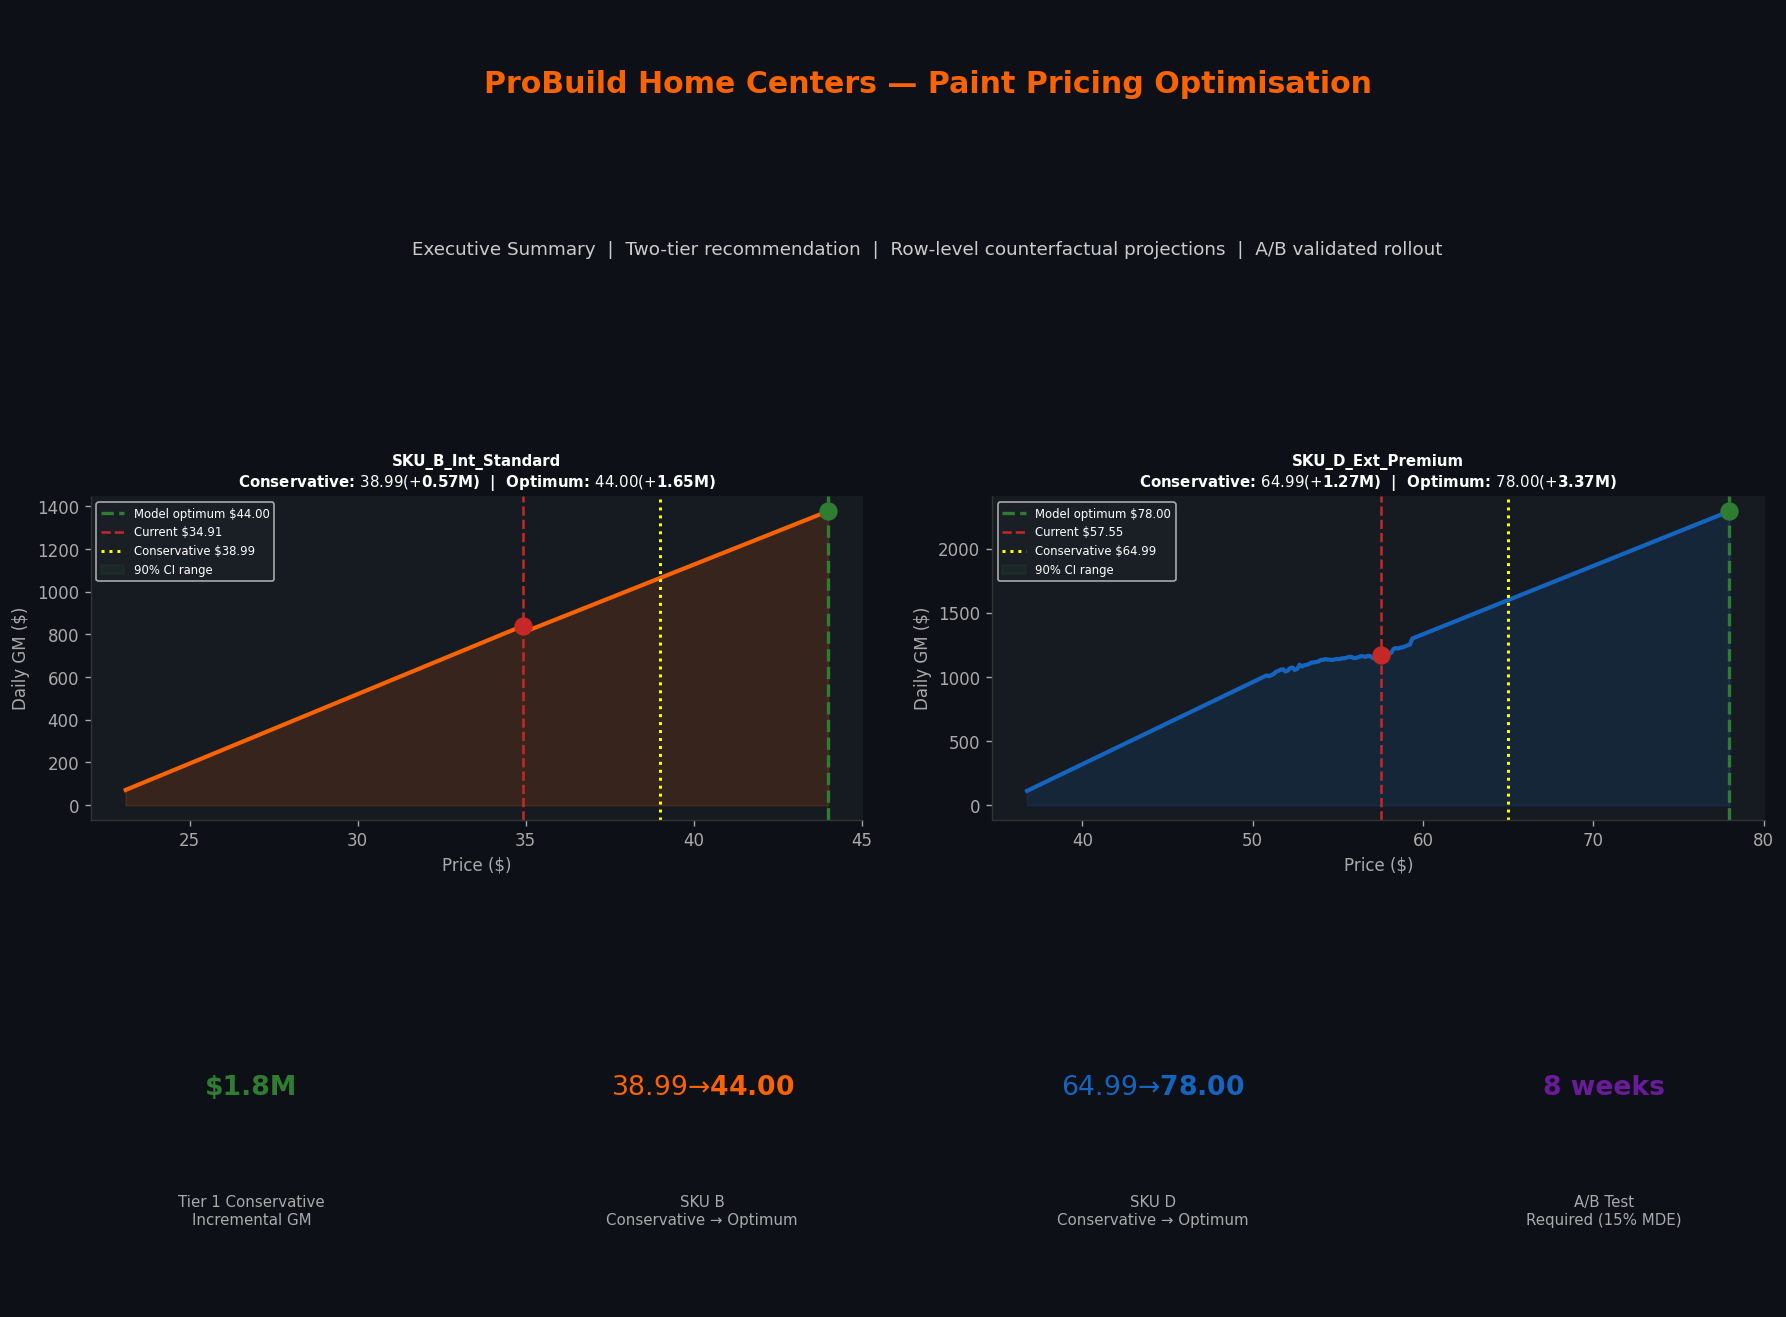

In [39]:
fig = plt.figure(figsize=(18, 14))
fig.patch.set_facecolor('#0D1117')
gs  = GridSpec(3, 4, figure=fig, hspace=0.5, wspace=0.4)

# Header
ax_h = fig.add_subplot(gs[0, :])
ax_h.set_facecolor('#0D1117')
ax_h.axis('off')
ax_h.text(0.5, 0.75,
          'ProBuild Home Centers — Paint Pricing Optimisation',
          transform=ax_h.transAxes, ha='center', fontsize=18,
          fontweight='bold', color=HD_ORANGE)
ax_h.text(0.5, 0.25,
          'Executive Summary  |  Two-tier recommendation  |  '
          'Row-level counterfactual projections  |  A/B validated rollout',
          transform=ax_h.transAxes, ha='center', fontsize=11, color='#CCCCCC')

for col, (sku, s) in enumerate(sweep_results.items()):
    ax    = fig.add_subplot(gs[1, col*2:(col+1)*2])
    color = HD_ORANGE if col == 0 else BLUE
    ax.set_facecolor('#161B22')

    # Defensible range
    ax.plot(s['price_grid'], s['margins'], color=color, linewidth=2.5)
    ax.fill_between(s['price_grid'], s['margins'], alpha=0.15, color=color)

    ax.axvline(s['p_opt'],         color=GREEN, linestyle='--', linewidth=2,
               label=f"Model optimum ${s['p_opt']:.2f}")
    ax.axvline(s['current_price'], color=RED,   linestyle='--', linewidth=1.5,
               label=f"Current ${s['current_price']:.2f}")

    con_price = conservative_prices[sku]
    ax.axvline(con_price, color='yellow', linestyle=':', linewidth=1.8,
               label=f"Conservative ${con_price:.2f}")

    # Bootstrap CI shading
    br = bootstrap_results[sku]
    ax.axvspan(br['p_ci'][0], br['p_ci'][4],
               alpha=0.1, color=GREEN, label='90% CI range')

    ax.scatter([s['p_opt']],         [s['mg_opt']], s=100, color=GREEN,  zorder=5)
    ax.scatter([s['current_price']], [s['mg_cur']],  s=100, color=RED,    zorder=5)


    proj_cur = project_counterfactual(sku, s['current_price'])
    proj_rec = project_counterfactual(sku, s['p_opt'])
    proj_con = project_counterfactual(sku, con_price)
    inc_rec  = (proj_rec['annual_gm'] - proj_cur['annual_gm']) / 1e6
    inc_con  = (proj_con['annual_gm'] - proj_cur['annual_gm']) / 1e6

    ax.set_title(
        f'{sku}\n'
        f'Conservative: ${con_price:.2f} (+${inc_con:.2f}M)  |  '
        f'Optimum: ${s["p_opt"]:.2f} (+${inc_rec:.2f}M)',
        color='white', fontsize=9)
    ax.set_xlabel('Price ($)', color='#AAAAAA')
    ax.set_ylabel('Daily GM ($)', color='#AAAAAA')
    ax.tick_params(colors='#AAAAAA')
    for spine in ax.spines.values():
        spine.set_color('#333333')
    ax.legend(fontsize=7, facecolor='#1C2128', labelcolor='white')

# Metric cards (row 2)
metrics = [
    ('Tier 1 Conservative\nIncremental GM',
     f'${total_incremental_conservative/1e6:.1f}M',
     GREEN),
    ('SKU B\nConservative → Optimum',
     f'${conservative_prices["SKU_B_Int_Standard"]:.2f} → '
     f'${sweep_results["SKU_B_Int_Standard"]["p_opt"]:.2f}',
     HD_ORANGE),
    ('SKU D\nConservative → Optimum',
     f'${conservative_prices["SKU_D_Ext_Premium"]:.2f} → '
     f'${sweep_results["SKU_D_Ext_Premium"]["p_opt"]:.2f}',
     BLUE),
    ('A/B Test\nRequired (15% MDE)',
     '8 weeks',
     PURPLE),
]

for col, (label, value, color) in enumerate(metrics):
    ax = fig.add_subplot(gs[2, col])
    ax.set_facecolor('#161B22')
    ax.axis('off')
    ax.text(0.5, 0.65, value,
            transform=ax.transAxes, ha='center',
            fontsize=16, fontweight='bold', color=color)
    ax.text(0.5, 0.25, label,
            transform=ax.transAxes, ha='center',
            fontsize=9, color='#AAAAAA')
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2)
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)

plt.show()